# Анализ лояльности пользователей Яндекс Афиши

## Этапы выполнения проекта

### 1. Загрузка данных и их предобработка

In [95]:
import os
from urllib.parse import quote_plus
from sqlalchemy import create_engine
from dotenv import load_dotenv

# Загружаем переменные из .env
load_dotenv(override=True)

# Кодируем пароль (защита от $ и ;)
password = quote_plus(os.getenv('DB_PASSWORD'))

# Создаём engine БЕЗ хардкода пароля
engine = create_engine(
    f"postgresql://{os.getenv('DB_USER')}:{password}"
    f"@{os.getenv('DB_HOST')}:{int(os.getenv('DB_PORT'))}/{os.getenv('DB_NAME')}"
)

print("✅ engine создан через .env")

✅ engine создан через .env


In [83]:
#устанавливаем библиотеку sqlalchemy:
!pip install sqlalchemy

Defaulting to user installation because normal site-packages is not writeable


In [84]:
#устанавливаем модуль psycopg2:
import sys
!{sys.executable} -m pip install psycopg2-binary

Defaulting to user installation because normal site-packages is not writeable


In [85]:
!{sys.executable} -m pip install  phik

Defaulting to user installation because normal site-packages is not writeable


In [86]:
#импортируем необходимые библиотеки:
import pandas as pd
import numpy as np
from sqlalchemy import create_engine

In [87]:
#загружаем библиотеки для визуализации данных:
import matplotlib.pyplot as plt
import seaborn as sns

In [88]:
#формируем запрос для извлечения данных:

query = '''
SELECT 
    p.user_id,
    p.device_type_canonical,
    p.order_id,
    p.created_dt_msk AS order_dt,
    p.created_ts_msk AS order_ts,
    p.currency_code,
    p.revenue,
    p.tickets_count,
    (p.created_dt_msk::date-LAG(p.created_dt_msk::date) OVER (PARTITION BY p.user_id ORDER BY p.created_dt_msk::date))::int AS days_since_prev,
    e.event_name_code AS event_name,
    e.event_type_main,
    p.service_name,
    r.region_name,
    c.city_name
FROM afisha.purchases AS p
INNER JOIN afisha.events  AS e ON p.event_id = e.event_id
INNER JOIN afisha.city    AS c ON e.city_id = c.city_id
INNER JOIN afisha.regions AS r ON c.region_id = r.region_id
WHERE p.device_type_canonical IN ('mobile', 'desktop')
  AND e.event_type_main!='фильм'
ORDER BY p.user_id;


'''

In [89]:
#записываем результат запроса в датафрейм:
afisha_df= pd.read_sql_query(query, con=engine)

### Задача 1.2: Изучите общую информацию о выгруженных данных. Оцените корректность выгрузки и объём полученных данных.

In [90]:
afisha_df.head()

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_name,event_type_main,service_name,region_name,city_name
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaN,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,театр,Край билетов,Каменевский регион,Глиногорск
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaN,40efeb04-81b7-4135-b41f-708ff00cc64c,выставки,Мой билет,Каменевский регион,Глиногорск
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,75.0,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,другое,За билетом!,Каменевский регион,Глиногорск
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,NaN,2f638715-8844-466c-b43f-378a627c419f,другое,Лови билет!,Североярская область,Озёрск
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,83.0,10d805d3-9809-4d8a-834e-225b7d03f95d,стендап,Билеты без проблем,Озернинский край,Родниковецк


In [91]:
afisha_df.columns

Index(['user_id', 'device_type_canonical', 'order_id', 'order_dt', 'order_ts',
       'currency_code', 'revenue', 'tickets_count', 'days_since_prev',
       'event_name', 'event_type_main', 'service_name', 'region_name',
       'city_name'],
      dtype='object')

In [92]:
afisha_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  object        
 1   device_type_canonical  290611 non-null  object        
 2   order_id               290611 non-null  int64         
 3   order_dt               290611 non-null  datetime64[ns]
 4   order_ts               290611 non-null  datetime64[ns]
 5   currency_code          290611 non-null  object        
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int64         
 8   days_since_prev        268678 non-null  float64       
 9   event_name             290611 non-null  object        
 10  event_type_main        290611 non-null  object        
 11  service_name           290611 non-null  object        
 12  region_name            290611 non-null  obje

В данном датафрейме "afisha_df" отражена информация о мероприятиях в разных городах и покупках билетов на них. Информация содержит 290611 строк и 14 столбцов, из них 2 столбца представлены в виде числового типа данных с плавающей запятой(float64), 8 cтолбцов строкового(object) типа данных, 2 столбца целочисленного типа данных(integer) и 2 столбца типа времени и даты.
- Пропуски содержатся в столбце "days_since_prev", что обьясняется смыслом этой колонки, отсутствие повторных покупок среди клиентов.

Проанализируем подробнее тип данных каждого столбца:

- 'user_id' лучше оставить как строку object, так как по смыслу это идентификатор и в качестве строки при необходимости можно будет использовать для поиска конкретного заведения, обьединения с другими таблицами и проверки на дуликаты.
- 'device_type_canonical', 'currency_code', 'event_name', 'event_type_main ', 'service_name', 'region_name', 'city_name' содержат строковую информацию, что логично по смыслу и преоразования типа данных немтребуется. Единственно, скорее понадобится перевод в 'currency_code' к одному значению типа валюты.
- 'order_id', 'tickets_count' - имеет смысл оставить целочисленными с пониженнием разрядности.
-  'revenue', 'days_since_prev' - оставим как float, так как в значении выручки важна точность, а 'days_since_prev' который мы привели изначально к integer в sql, не может храниться в этом типе данных, из-за наличия null значений. 
- 'order_dt' и 'order_ts' оставляем как datetime , что подходит по смыслу.

- Названия столбцов уже в приемлемом однотипном виде, поэтому приведения к snake case не требуется.

### 2. Предобработка данных

###  Задача 2.1: Данные о выручке сервиса представлены в российских рублях и казахстанских тенге. Приведение выручки к единой валюте — российскому рублю.

In [12]:
#проверим соотношение количества строк в единицах rub и kzt:
afisha_df['currency_code'].value_counts()

currency_code
rub    285542
kzt      5069
Name: count, dtype: int64

Получается kzt: 5069 заказов—около 1,7% от всех данных.

In [13]:
#выгружаем в датасет с информацией о курсе
tenge=pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')

In [14]:
tenge.head()

,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt


In [15]:
#приведем data из датафрейма tenge к типу datetime:
tenge['data']= pd.to_datetime(tenge['data'])

In [16]:
#соединяем заказы с курсом по дате:
df=afisha_df.merge(
   tenge[['data', 'nominal', 'curs']],
   left_on='order_dt',
   right_on='data',
   how='left'
)

In [17]:
#Считаем revenue_rub через np.where:
#Если валюта kzt—умножаем на курс и делим на номинал.
#Иначе(rub)—оставляем выручку без изменений.
df['revenue_rub']=np.where(
    df['currency_code']=='kzt',
    df['revenue']*df['curs']/df['nominal'],
    df['revenue']
)

In [18]:
#округляем выручку:
df['revenue_rub']= df['revenue_rub'].round(2)

In [19]:
#проверка:
print(df[['order_dt', 'currency_code', 'revenue', 'curs', 'revenue_rub']].head(10))
print()
print('Первые строки с тенге:')
print(df[df['currency_code']=='kzt'][['order_dt', 'revenue', 'curs', 'revenue_rub']].head(5))

    order_dt currency_code  revenue     curs  revenue_rub
0 2024-08-20           rub  1521.94  18.6972      1521.94
1 2024-07-23           rub   289.45  18.3419       289.45
2 2024-10-06           rub  1258.57  19.6475      1258.57
3 2024-07-13           rub     8.49  18.5010         8.49
4 2024-10-04           rub  1390.41  19.6648      1390.41
5 2024-10-23           rub   902.74  20.0531       902.74
6 2024-08-15           rub   917.83  18.7730       917.83
7 2024-09-29           rub    47.78  19.3741        47.78
8 2024-10-15           rub    74.84  19.7185        74.84
9 2024-06-20           rub   710.95  18.0419       710.95

Первые строки с тенге:
      order_dt   revenue     curs  revenue_rub
70  2024-09-17    518.10  19.0125        98.50
89  2024-09-02    347.18  18.9330        65.73
96  2024-09-09    328.77  18.5991        61.15
277 2024-06-11  22021.55  19.8928      4380.70
460 2024-06-04   7397.66  19.9833      1478.30


Итак, в ходе проверки мы видим что создали новую колонку 'revenu_rub' и для значений с тенге преобрапзование по формуле произошло успешно.

### Задача 2.2:

Проверка данных на пропущенные значения:

In [20]:
#Количество пропусков:
df.isna().sum()

user_id                      0
device_type_canonical        0
order_id                     0
order_dt                     0
order_ts                     0
currency_code                0
revenue                      0
tickets_count                0
days_since_prev          21933
event_name                   0
event_type_main              0
service_name                 0
region_name                  0
city_name                    0
data                         0
nominal                      0
curs                         0
revenue_rub                  0
dtype: int64

В итоге, null значения были обнаружены только в колонке 'days_since_prev', что является естественным по смыслу, так как отражает количество дней от предыдущей покупки пользователя, соответственно  21933 пользователей совершили одну покупку.

Преобразование типов данных:

In [21]:
#оптимизируем целочисленные типы данных 'order_id', 'tickets_count':
df['order_id']= pd.to_numeric(df['order_id'], downcast='integer')
df['tickets_count']= pd.to_numeric(df['tickets_count'], downcast='integer')

In [22]:
#преобразуем 'days_since_prev' в целочисленный тип с заменой null на -1,
#так как при зпамене на 0 это можно было бы интерпретироваться 
#как повторная покупка в тот же день:
df['days_since_prev']=df['days_since_prev'].fillna(-1).astype('int32')

In [23]:
#Столбцы device_type_canonical, currency_code содержат повторяющиеся 
#значения (всего 2 типа устройств, 2 валюты). Их можно превратить в category:
for col in ['device_type_canonical', 'currency_code']:
    df[col]=df[col].astype('category')

В результате преобразования типов данных были оптимизированы целочисленные типы данных 'order_id', 'tickets_count' c понижением разрядности. Столбец с выручкой 'revenue' оставили как есть, так как переход на float32 теряет точность после 7 знаков, что имеет значение для денег. 'days_since_prev' преобразовали в целочисленный, так как тип float появился из-за пропусков: pandas не может хранить nan в int, поэтому автоматически превратил столбец в float. Можно было бы и не переводить в int количество дней,  так как nan тут имеет смысл. 'device_type_canonical', 'currency_code' можно превратить в category— это экономит память в разы. 'order_dt' и 'order_ts'— datetime64, Это подходящий тип для дат и времени. Ничего делать не надо, они уже в правильном формате.

In [24]:
#проверка на аномалии:
print("Отрицательные значения в revenue_rub:", (df['revenue_rub']<0).sum())
print("Нулевые значения в revenue_rub:", (df['revenue_rub']==0).sum())
print("Отрицательные в tickets_count:", (df['tickets_count']<0).sum())

Отрицательные значения в revenue_rub: 381
Нулевые значения в revenue_rub: 5526
Отрицательные в tickets_count: 0


- 381 отрицательное значение в revenue_rub— это ошибки в данных. Выручка не может быть отрицательной для проданного заказа. Скорее это возвраты с отрицательной суммой, технический сбой  или ошибка.
- 5526 нулевых значений— тоже подозрительно. Заказ с нулевой выручкой может означать: бесплатные билеты/промо, ошибку (заказ создан, но не оплачен).

Отрицательные значения в revenue_rub— это явные аномалии, удалим их, так как 381 строк по сравнению с общими 290611 не так много чтобы влиять на целую картину. 

In [25]:
#удаляем строки с отрицательной выручкой с использованием булевой маски
#и созданием копии и присвоением ее обратно  в переменную
rows_before= len(df)
df= df[df['revenue_rub']>=0].copy()
rows_after= len(df)
print(f"Осталось строк с отрицательной выручкой: {rows_before-rows_after}")


Осталось строк с отрицательной выручкой: 381


In [26]:
#Обработка категориальных столбцов:
#Список категориальных столбцов:
cat_cols = ['device_type_canonical', 'currency_code', 'event_type_main',
            'service_name', 'region_name', 'city_name']

#Уникальные значения в каждом столбце:
for col in cat_cols:
    print(f"\n{col}:")
    print(f"Количество уникальных значений: {df[col].nunique()}")
    print(f"Пропусков (NaN): {df[col].isna().sum()}")
    print(f"Уникальные значения: {df[col].unique()}")


device_type_canonical:
Количество уникальных значений: 2
Пропусков (NaN): 0
Уникальные значения: ['mobile', 'desktop']
Categories (2, object): ['desktop', 'mobile']

currency_code:
Количество уникальных значений: 2
Пропусков (NaN): 0
Уникальные значения: ['rub', 'kzt']
Categories (2, object): ['kzt', 'rub']

event_type_main:
Количество уникальных значений: 7
Пропусков (NaN): 0
Уникальные значения: ['театр' 'выставки' 'другое' 'стендап' 'концерты' 'спорт' 'ёлки']

service_name:
Количество уникальных значений: 36
Пропусков (NaN): 0
Уникальные значения: ['Край билетов' 'Мой билет' 'За билетом!' 'Лови билет!'
 'Билеты без проблем' 'Облачко' 'Лучшие билеты' 'Прачечная' 'Быстробилет'
 'Дом культуры' 'Весь в билетах' 'Билеты в руки' 'Тебе билет!'
 'Show_ticket' 'Городской дом культуры' 'Яблоко' 'Билет по телефону'
 'Выступления.ру' 'Росбилет' 'Шоу начинается!' 'Мир касс' 'Восьмёрка'
 'Телебилет' 'Crazy ticket!' 'Реестр' 'Быстрый кассир' 'КарандашРУ'
 'Радио ticket' 'Дырокол' 'Вперёд!' 'Кино 

Нормализация не потребовалась, так как данные изначально находятся в 
корректном виде: единый регистр, отсутствие лишних пробелов и nan.

In [27]:
print("Статистика revenue_rub:")
print(df['revenue_rub'].describe())
print()
print("Статистика tickets_count:")
print(df['tickets_count'].describe())

Статистика revenue_rub:
count    290230.000000
mean        556.304590
std         875.838946
min           0.000000
25%         114.610000
50%         352.080000
75%         802.250000
max       81174.540000
Name: revenue_rub, dtype: float64

Статистика tickets_count:
count    290230.000000
mean          2.755149
std           1.170634
min           1.000000
25%           2.000000
50%           3.000000
75%           4.000000
max          57.000000
Name: tickets_count, dtype: float64


Исходя из статистики по выручке в рублях (revenue_rub) мы видим:
- минимальное значение равно 0, соответственно строки с отрицательной выручкой были удалены.
- cреднее (556.30) сильно больше медианы (352.08) изначает, что большинство заказов дешёвые, но есть крупные, которые тянут среднее вверх.
- cтандартное отклонение (875.84) дает очень большой разброс, то есть  данные очень неоднородны.
- максимум 81 174.54—это 232 раза больше медианы (352.08). Такой огромный разрыв говорит о наличии выбросов. Именно их нужно отсечь по 99-му перцентилю.


Статистика количества купленных билетов:
- распределение почти симметричное—среднее (2.76) и  медиана (3.00) почти равны. Никакого скошения нет.
- небольшой разброс—std всего 1.17 при среднем 2.76. Значит, значения плотно сгруппированы вокруг 2–4 билетов.
- типичный заказ— 2–4 билета (межквартильный диапазон от 2 до 4). Это логично: большинство покупает билеты для пары или семьи.
- максимум= 57 билетов— это потенциальный выброс (в 20 раз больше медианы). Но это может быть реальная корпоративная закупка, а не ошибка.
- нет отрицательных значений— данные чистые.


Вычислим межквартильный размах (IQR) выручки в рублях:<br>
Q1= 114.61, Q3 = 802.25<br>
IQR= 802.25−114.61=687.64<br>
Верхняя граница усов (по правилу 1.5·IQR): 802.25+1.5×687.64=1833.71<br>

Всё, что выше 1833.71 рублей— потенциальный выброс. Это подтверждает, что выбросы есть.

Проверим топ-10 самых дорогих заказов(выбросы) является ли это ошибкой или реалтные данные:

In [28]:
#топ-10 самых дорогих заказов:
print(df.nlargest(10, 'revenue_rub')[['order_id', 'event_name', 'event_type_main', 'tickets_count', 'revenue_rub', 'currency_code']])

        order_id                            event_name event_type_main  \
122337   4113477  b443dc5a-fff2-4b69-8684-0719fff49b59        концерты   
122338   4113535  b443dc5a-fff2-4b69-8684-0719fff49b59        концерты   
183750   8067453  b443dc5a-fff2-4b69-8684-0719fff49b59        концерты   
111504   8330309  b443dc5a-fff2-4b69-8684-0719fff49b59        концерты   
111934   6492608  b443dc5a-fff2-4b69-8684-0719fff49b59        концерты   
122336   4113506  b443dc5a-fff2-4b69-8684-0719fff49b59        концерты   
198767   7150734  b443dc5a-fff2-4b69-8684-0719fff49b59        концерты   
235142   4299860  b443dc5a-fff2-4b69-8684-0719fff49b59        концерты   
11121    3329694  b443dc5a-fff2-4b69-8684-0719fff49b59        концерты   
28942    4874988  b443dc5a-fff2-4b69-8684-0719fff49b59        концерты   

        tickets_count  revenue_rub currency_code  
122337              5     81174.54           rub  
122338              5     81174.54           rub  
183750              5     81174.

Мы видим, что у всех заказов одинаковый event_name и event_type_main,  а также цена одного билета является одинаковой (16234.9 руб), соответственно это реалтные данные,  скорее продажи на один концерт (VIP места или дорогостоящий концерт мировой звезды).  Однако все-равно провелдем фильтрацию, так как эти заказы искажают средние и их очень мало (несколько десятков из 290 000).

In [29]:
#cчитаем 99-й перцентиль:
p99= df['revenue_rub'].quantile(0.99)
print(f"99-й перцентиль revenue_rub: {p99:.2f}")

99-й перцентиль revenue_rub: 2628.42


In [30]:
#фильтруем:
df=df[df['revenue_rub']<=p99].copy()

In [31]:
#проверка:
print("Максимум revenue_rub:", df['revenue_rub'].max())
print("99-й перцентиль был:", p99)
print("Есть ли значения выше p99:", (df['revenue_rub']>p99).sum())
print("Осталось строк:", len(df))

Максимум revenue_rub: 2628.42
99-й перцентиль был: 2628.42
Есть ли значения выше p99: 0
Осталось строк: 287405


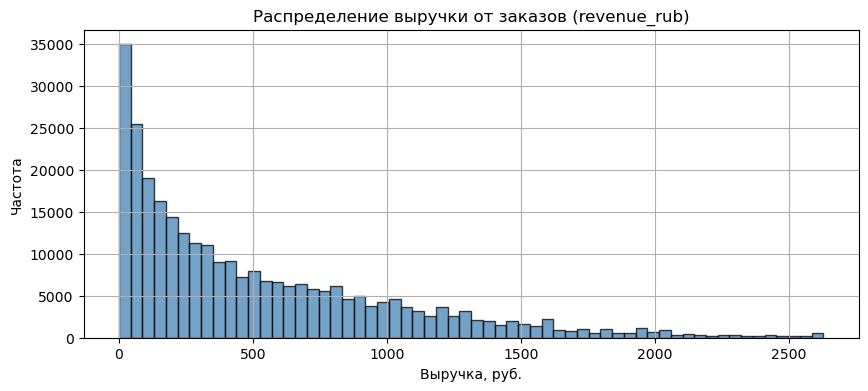

In [32]:
#создаём контейнер и задаём его размер:
plt.figure(figsize=(10, 4))

#строим гистограмму с помощью pandas через plot(kind='hist'):
df['revenue_rub'].plot(
                kind='hist',           
                bins=60,              
                alpha=0.75,           
                edgecolor='black',     
                color='steelblue',    
                rot=0,                
)

#настраиваем оформление графика:
plt.title('Распределение выручки от заказов (revenue_rub)')
plt.xlabel('Выручка, руб.')
plt.ylabel('Частота')
#добавляем сетку графика:
plt.grid()

#выводим график
plt.show()

Гистограмма revenue_rub (после фильтрации по p99):
Ожидаемая форма: резкий пик в районе низких значений (0–500 руб) и плавно затухающий хвост до 2628 руб.

Это значит:
- большинство заказов дешёвые—основной объём в первых корзинах (0–500 руб).
- длинный правый хвост—есть заказы на 1000–2600 руб, но их уже намного меньше.
- скошение вправо сохраняется даже после фильтрации—это норма для денежных данных.

Резкого обрыва на 2628.42 быть не должно визуально, но именно там теперь кончается гистограмма.

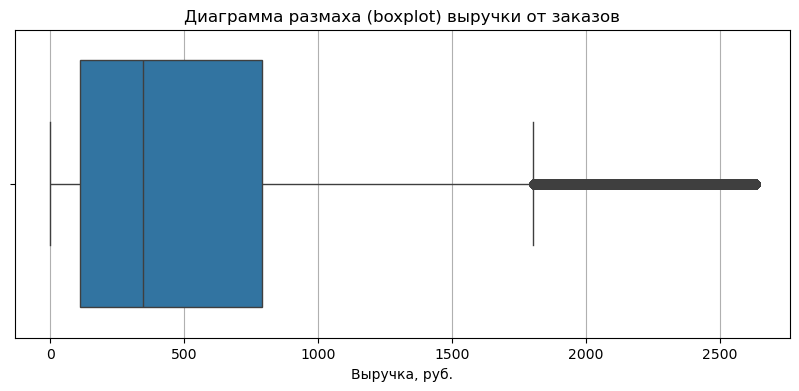

In [33]:
plt.figure(figsize=(10, 4))

# Строим boxplot по одному столбцу
sns.boxplot(x='revenue_rub', data=df)

plt.title('Диаграмма размаха (boxplot) выручки от заказов')
plt.xlabel('Выручка, руб.')
plt.grid(True, axis='x')
plt.show()

 График полностью подтверждает то, что мы видели в статистике и на гистограмме:
- Правостороннее скошение распределения — медиана (352) смещена влево от центра ящика (центр был бы 460). Левый ус короткий, правый— длинный.
- Левая граница ящика 115 руб— это 25-й перцентиль.Медиана (352 руб)— 50-й перцентиль. Правая граница ящика (802 руб)— 75-й перцентиль. Центральные 50% заказов лежат в диапазоне 115–802 руб. Это типичные заказы сервиса.
- Много выбросов— значения от 1834 до 2628 руб. Boxplot считает их выбросами, но они прошли фильтр. Это нормальное расхождение между двумя критериями. 
- Левый ус уходит влево до 0 руб. Минимум revenue_rub= 0 (нулевые заказы, промо-билеты). Это норма.



In [34]:
#рассчитаем обьем удаленных данных:
rows_before, rows_mid, rows_after= 290611, 290230, 287405

#сколько удалено отрицательных значений (%):
per_neg= (rows_before-rows_mid)/rows_before*100  
#cколько удалено выбросов по p99 (%):
per_p99 = (rows_mid-rows_after)/rows_mid*100  
#cколько всего удалено (%):
per_total= (rows_before-rows_after)/rows_before*100

print(f"Удалено отрицательных: {per_neg:.2f}%")
print(f"Удалено выбросов по p99: {per_p99:.2f}%")
print(f"Всего удалено: {per_total:.2f}%")

Удалено отрицательных: 0.13%
Удалено выбросов по p99: 0.97%
Всего удалено: 1.10%


В ходе предобработки данных было выполнено несколько шагов:

1 Преобразование типов данных:

- Были оптимизированы целочисленные типы данных 'order_id', 'tickets_count' c понижением разрядности. 
- Столбец с выручкой 'revenue' оставили как есть, так как переход на float32 теряет точность после 7 знаков, что имеет значение для денег. 
- 'days_since_prev' преобразовали в целочисленный, так как тип float появился из-за пропусков: pandas не может хранить nan в int, поэтому автоматически превратил столбец в float. Можно было бы и не переводить в int количество дней, так как nan тут имеет смысл. 
- 'device_type_canonical', 'currency_code' превратили в category— это экономит память в разы. 
- 'order_dt' и 'order_ts'— datetime64, Это подходящий тип для дат и времени.

2 Изучение ключевых revenue_rub (выручка в рублях) и tickets_count (количество билетов в заказе) столбцов и обработка аномалий:

- Проверка на аномалии показала: 381 отрицательное значение в revenue_rub—это явные ошибки выгрузки, ведь выручка от проданного заказа не может быть отрицательной.
- 5526 нулевых значений были оставлены, так как они могут обозначать промо-билеты или бесплатные входы;
- Отрицательных значений в tickets_count нет—данные по количеству билетов чистые.

Отрицательные значения выручки были удалены, после чего в датасете осталось 290230 строк (было 290611).

2 Проверка категориальных столбцов:

Нормализация не потребовалась, так как данные изначально находятся в корректном виде: единый регистр, отсутствие лишних пробелов и nan.

3. Анализ распределений:

Для проверки распределений были использованы три инструмента: статистические показатели(describe), гистограмма и диаграма размаха (boxplot).Результат показал:

- revenue_rub сильно скошено вправо: среднее (556 руб) значительно больше медианы (352 руб), есть длинный хвост крупных заказов. Это типичная картина для денежных данных.

- tickets_count распределено почти симметрично: среднее (2.76) близко к медиане (3.0). Типичный заказ— 2–4 билета.

Изучив топ-10 самых дорогих заказов, мы увидели, что все они относятся к одному и тому же концерту с одинаковой ценой за билет (16235 руб.). Это не ошибки, а реальные дорогие заказы, но они сильно искажают средние показатели и распределение. Поэтому было принято решение их удалить.

4. Фильтрация выбросов:

По требованию задачи я отфильтровала выбросы в revenue_rub по 99-му перцентилю, который составил 2628.42 руб. Все заказы с выручкой выше этого значения были удалены.

5. Оценка объёма отфильтрованных данных:

Исходный датасет df содержал 290611 строк. После удаления 381 отрицательного значения выручки (это явные ошибки выгрузки— выручка от проданного заказа не может быть отрицательной) осталось 290230 строк, что составило 0.13% от исходного объёма.

Далее был рассчитан 99-й перцентиль по столбцу revenue_rub, который составил 2628.42 руб. Все заказы с выручкой выше этого значения были удалены. На этом этапе отфильтровано 2825 строк— это 0.97% от размера данных после первого этапа очистки. 

Итого было удалено 3206 строк, что составляет 1.10% от исходного объёма данных. Проверка сходится: 287405 = 290611 −381−2 825.

Итоговый процент удаления—1.10% — незначителен и не влияет на репрезентативность выборки. Данные остаются пригодными для анализа: удалены только явные ошибки и верхний 1% крупных заказов, которые сильно искажали средние показатели и распределение. Оставшиеся 287405 строк (98.90% исходных данных) содержат очищенную и подготовленную к дальнейшему анализу информацию.

6. Описание новых столбцов:

В результате предобработки в датасете появились следующие столбцы:

- revenue_rub— выручка, приведённая к российским рублям. Для заказов в тенге (kzt) значение пересчитано по курсу на дату заказа (revenue×curs/nominal), для рублей (rub)—оставлено без изменений.
- days_since_prev— количество дней с предыдущего заказа пользователя. Для первой покупки стоит значение -1, тип int32.





### 3  Создание профиля пользователя:

### Задача 3.1. Построение профиля пользователя:

In [35]:
#cортируем по времени (для каждогоuser_id строки идут по возрастанию order_ts):
#создавая копию датафрейма
df_sorted=df.sort_values(by=['user_id', 'order_ts']).copy()

In [36]:
#разница с предыдущим заказом:
df_sorted['prev_order']= df_sorted.groupby('user_id')['order_ts'].shift(1)
df_sorted['days_between']= (df_sorted['order_ts']-df_sorted['prev_order']).dt.days 

In [37]:
#профиль пользователя, сбрасывая индекс делая user_id обычным столбцом:
user_profile=df_sorted.groupby('user_id').agg(
    #дата первого и последнего заказа
    first_order_dt=('order_dt', 'min'),
    last_order_dt=('order_dt', 'max'),

    #устройство первого заказа
    first_device=('device_type_canonical', 'first'),

    #регион первого заказа
    first_region=('region_name', 'first'),

    #билетный партнёр первого заказа
    first_service=('service_name', 'first'),

    #жанр первого мероприятия
    first_event_type=('event_type_main', 'first'),

    #общее количество заказов
    orders_count=('order_id', 'count'),

    #средняя выручка с одного заказа
    avg_revenue=('revenue_rub', 'mean'),

    #среднее количество билетов в заказе
    avg_tickets=('tickets_count', 'mean'),

    #среднее время между заказами
    avg_days_between=('days_between', 'mean'),
).reset_index()

In [38]:
#добавляем бинарные признаки
#is_two — совершил ли пользователь 2 и более заказа.
#is_five — совершил ли пользователь 5 и более заказов.
user_profile['is_two']=(user_profile['orders_count']>=2).astype(int)
user_profile['is_five']=(user_profile['orders_count']>=5).astype(int)


In [39]:
#проверка:
print(f"Размер профиля: {user_profile.shape}")
print(f"Количество уникальных пользователей: {user_profile['user_id'].nunique()}")
print()
print("Первые 5 строк профиля:")
print(user_profile.head())
print()
print("Столбцы профиля:")
print(user_profile.columns)
print()
print("Распределение бинарных признаков:")
print(user_profile[['is_two', 'is_five']].value_counts())

Размер профиля: (21838, 13)
Количество уникальных пользователей: 21838

Первые 5 строк профиля:
           user_id first_order_dt last_order_dt first_device  \
0  0002849b70a3ce2     2024-08-20    2024-08-20       mobile   
1  0005ca5e93f2cf4     2024-07-23    2024-10-06       mobile   
2  000898990054619     2024-07-13    2024-10-23       mobile   
3  00096d1f542ab2b     2024-08-15    2024-08-15      desktop   
4  000a55a418c128c     2024-09-29    2024-10-15       mobile   

           first_region  first_service first_event_type  orders_count  \
0    Каменевский регион   Край билетов            театр             1   
1    Каменевский регион      Мой билет         выставки             2   
2  Североярская область    Лови билет!           другое             3   
3    Каменевский регион   Край билетов            театр             1   
4      Поленовский край  Лучшие билеты            театр             2   

   avg_revenue  avg_tickets  avg_days_between  is_two  is_five  
0  1521.940000 

### Задача 3.2 анализ на репрезентативность данных и  аномалии в профиле пользователя.

#### Базовые метрики по профилю:

In [40]:
#общее число пользователей
total_users= user_profile['user_id'].nunique()
print(f"Общее число пользователей: {total_users}")

#средняя выручка с одного заказа 
avg_revenue_per_order= user_profile['avg_revenue'].mean()
print(f"Средняя выручка с одного заказа: {avg_revenue_per_order:.2f} руб.")

#доля пользователей с 2+ заказами
share_two= user_profile['is_two'].mean()*100
print(f"Доля пользователей с 2+ заказами: {share_two:.2f}%")

#доля пользователей с 5+ заказами
share_five = user_profile['is_five'].mean()*100
print(f"Доля пользователей с 5+ заказами: {share_five:.2f}%")

Общее число пользователей: 21838
Средняя выручка с одного заказа: 545.03 руб.
Доля пользователей с 2+ заказами: 61.70%
Доля пользователей с 5+ заказами: 29.00%


#### Статистические показатели:

In [41]:
print("Общее число заказов (orders_count)")
print(user_profile['orders_count'].describe())
print()

print("Среднее число билетов в заказе (avg_tickets)")
print(user_profile['avg_tickets'].describe())
print()

print("Среднее количество дней между покупками (avg_days_between)")
print(user_profile['avg_days_between'].describe())

Общее число заказов (orders_count)
count    21838.000000
mean        13.160775
std        121.577370
min          1.000000
25%          1.000000
50%          2.000000
75%          5.000000
max      10168.000000
Name: orders_count, dtype: float64

Среднее число билетов в заказе (avg_tickets)
count    21838.000000
mean         2.744062
std          0.913083
min          1.000000
25%          2.000000
50%          2.750000
75%          3.080000
max         11.000000
Name: avg_tickets, dtype: float64

Среднее количество дней между покупками (avg_days_between)
count    13475.000000
mean        15.621034
std         22.204632
min          0.000000
25%          0.814124
50%          7.916667
75%         20.000000
max        148.000000
Name: avg_days_between, dtype: float64


Cтатистические показатели:
1 Общее число заказов (orders_count):
- Среднее (13.16) в 6.5 раз больше медианы (2.00)—сильнейшее правостороннее скошение.
- Максимум (10168 заказов)—это более чем в 2000 раз больше медианы. Один пользователь сделал 10168 заказов—это физически невозможно для реального человека.
- Std (121.58) в 9 раз больше среднего—признак огромного разброса.

Оставлять их нельзя—один такой пользователь исказит все средние показатели.

2 Среднее число билетов в заказе (avg_tickets):

- Среднее примерно равно медиане—распределение симметричное, это хорошо.
- Max=11 билетов—может быть как реальная корпоративная закупка (11 билетов на концерт— нормально).
- Std (0.91)—небольшой разброс, данные плотно сгруппированы.

Здесь аномалия слабая. 11 билетов в среднем на заказ у одного пользователя—реально (например, организатор мероприятия покупал много билетов).

3 Среднее количество дней между покупками (avg_days_between):

- Медиана (7.92 дня)—половина пользователей покупает билеты раз в неделю.
- Среднее (15.62)—смещено вправо длинным хвостом редких покупателей.
- Max 148 дней—около 5 месяцев между заказами. Это реально (человек ходит на концерты 2 раза в год).
- Count=13475 из всего 21 838. У 8363 пользователей (38%) всего 1 заказ.

Аномалий нет. Значение Nan для однократных покупателей—логично.

Итого, лучше отфильтровать orders_count по 99-му перцентилю. Там явные ошибки (10168 заказов—невозможно).
Один такой пользователь исказит средние по всей выборке.


Фильтрация orders_count по 99-му перцентилю:

In [42]:
#размер до фильтрации
users_before= len(user_profile)
print(f"\nПользователей до фильтрации: {users_before}")


Пользователей до фильтрации: 21838


In [43]:
#считаем 99-й перцентиль по orders_count
p99_orders= user_profile['orders_count'].quantile(0.99)
print(f"99-й перцентиль orders_count: {p99_orders:.0f}")

99-й перцентиль orders_count: 152


In [44]:
#фильтруем: оставляем только пользователей с orders_count<=p99
user_profile_clean = user_profile[user_profile['orders_count']<=p99_orders].copy()

In [45]:
users_after= len(user_profile_clean)
removed= users_before-users_after
print(f"Пользователей после фильтрации: {users_after}")
print(f"Удалено: {removed} ({removed/users_before*100:.2f}%)")

Пользователей после фильтрации: 21622
Удалено: 216 (0.99%)


In [46]:
#статистика после фильтрации
print("Общее число заказов (orders_count)")
print(user_profile_clean['orders_count'].describe())
print()

print("Среднее число билетов в заказе (avg_tickets)")
print(user_profile_clean['avg_tickets'].describe())
print()

print("Среднее количество дней между покупками (avg_days_between)")
print(user_profile_clean['avg_days_between'].describe())

Общее число заказов (orders_count)
count    21622.000000
mean         6.496624
std         14.310784
min          1.000000
25%          1.000000
50%          2.000000
75%          5.000000
max        152.000000
Name: orders_count, dtype: float64

Среднее число билетов в заказе (avg_tickets)
count    21622.000000
mean         2.744256
std          0.917491
min          1.000000
25%          2.000000
50%          2.750000
75%          3.100000
max         11.000000
Name: avg_tickets, dtype: float64

Среднее количество дней между покупками (avg_days_between)
count    13259.000000
mean        15.871284
std         22.297321
min          0.000000
25%          1.000000
50%          8.066667
75%         20.500000
max        148.000000
Name: avg_days_between, dtype: float64


Оценка данных и обработка аномалий

1 Базовые метрики:

- Общее число пользователей—21838. Средняя выручка с одного заказа—545.03 руб. Доля пользователей, совершивших 2 и более заказа—61.70%. Доля пользователей, совершивших 5 и более заказов—29.00%.
Статистические показатели (до фильтрации):
- По числу заказов: среднее 13.16, медиана 2.00, стандартное отклонение 121.58, максимум 10168. По среднему числу билетов: среднее 2.74, медиана 2.75, std 0.91, максимум 11. По среднему времени между покупками: среднее 15.62 дня, медиана 7.92, std 22.20, максимум 148.

2 Обнаруженные аномалии:
- В столбце orders_count—серьёзная аномалия. Среднее (13.16) в 6.5 раз больше медианы (2.00)—сильнейшее правостороннее скошение. Максимум — 10168 заказов у одного пользователя. Это физически невозможно, значит, это технические ошибки— тестовые аккаунты, боты или ошибки привязки заказов.

- В столбце avg_tickets аномалий нет. Распределение симметричное: среднее (2.74) практически совпадает с медианой (2.75). Максимум—11 билетов, что правдоподобно (например, корпоративная закупка). Фильтрация не требуется.

- В столбце avg_days_between аномалий тоже нет. Медиана 7.92 дня, максимум 148 дней (около 5 месяцев)— реалистичные значения. Пропуски (NaN) у 8363 пользователей логичны: у них всего один заказ, предыдущего нет.

В итоге, было решено отфильтровать orders_count по 99-му перцентилю. Столбцы avg_tickets и avg_days_between оставлены без изменений.

3 Результат фильтрации:

Пользователей до фильтрации—21838. После—21622. Удалено 216 пользователей (0.99%). Порог отсечения (99-й перцентиль)— 52 заказа. Максимум orders_count после фильтрации — 152 (было 10168).

4 Статистика по обновлённому датасету:

По числу заказов: среднее 6.50, медиана 2.00, std 14.31, максимум 152. По среднему числу билетов: среднее 2.74, медиана 2.75, std 0.92, максимум 11— без изменений. По среднему времени между покупками: среднее 15.87 дня, медиана 8.07, std 22.30, максимум 148— без существенных изменений.

Итог:

После фильтрации среднее orders_count упало с 13.16 до 6.50 (в 2 раза), стандартное отклонение — с 121.58 до 14.31 (в 8.5 раз), максимум снизился с 10168 до 152 заказов. Это означает, что из данных удалены только ошибки, а реальные активные клиенты остались. Итоговый датасет (21622 пользователя) готов к дальнейшему анализу, а удалённые 0.99% данных не влияют на репрезентативность выборки.



## 4. Исследовательский анализ данных

### Задача 4.2.1. Cвязь между средней выручкой сервиса с заказа и повторными заказами.

In [47]:
#cредняя выручка с билета:
df['revenue_per_ticket']= df['revenue_rub']/df['tickets_count']

In [48]:
#разделим пользователей на группы:
#пользователи с одним заказом
single_users= user_profile_clean[user_profile_clean['orders_count']==1]

#пользователи с 2+ заказами:
returning_users= user_profile_clean[user_profile_clean['orders_count']>=2]

print(f"Однократные покупатели: {len(single_users)}")
print(f"Вернувшиеся покупатели: {len(returning_users)}")

Однократные покупатели: 8363
Вернувшиеся покупатели: 13259


In [49]:
#среднее значение выручки с билета по всем заказам пользователя:
rpt_profile = df.groupby('user_id')['revenue_per_ticket'].mean().reset_index()

#переименовываем, в дальнейшем в задании требуется это название
rpt_profile.columns= ['user_id', 'avg_revenue_rub']

In [50]:
#удаляем старый столбец, если он уже есть в профиле
if 'avg_revenue_rub' in user_profile_clean.columns:
    user_profile_clean = user_profile_clean.drop(columns=['avg_revenue_rub'])

#теперь merge безопасен—дубликатов не будет
user_profile_clean = user_profile_clean.merge(rpt_profile, on='user_id', how='left')

In [51]:
#разделим пользователей на группы:
#пользователи с одним заказом
single_users= user_profile_clean[user_profile_clean['orders_count']==1]

#пользователи с 2+ заказами:
returning_users= user_profile_clean[user_profile_clean['orders_count']>=2]

print(f"Однократные покупатели: {len(single_users)}")
print(f"Вернувшиеся покупатели: {len(returning_users)}")

Однократные покупатели: 8363
Вернувшиеся покупатели: 13259


Сравнительная гистограмма:

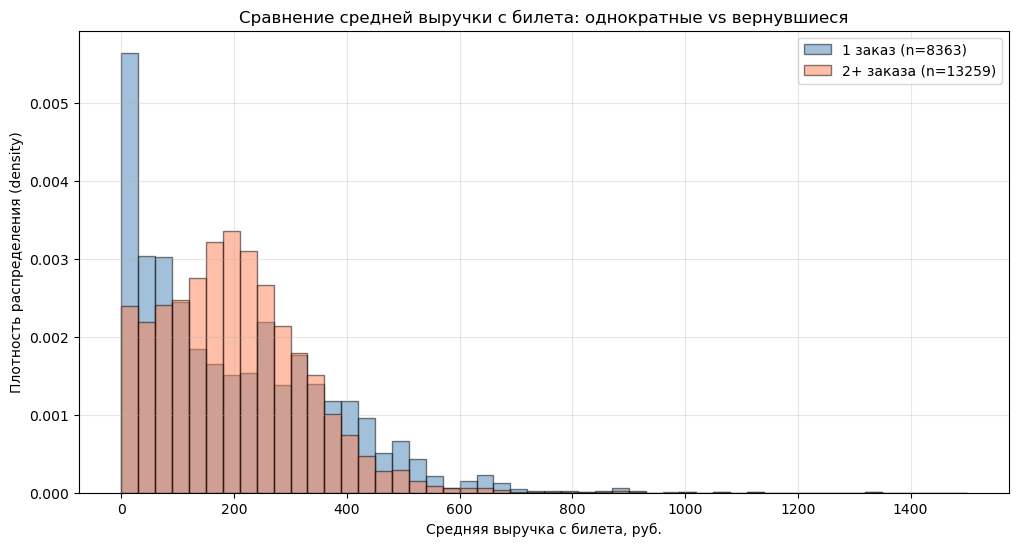

In [52]:
#задаём одинаковые интервалы (bins) для обеих групп
bins= np.linspace(0, 1500, 51)

plt.figure(figsize=(12, 6))

#гистограмма для однократных покупателей
plt.hist(single_users['avg_revenue_rub'].dropna(),
         bins=bins, alpha=0.5, color='steelblue',
         edgecolor='black', density=True,
         label=f"1 заказ (n={len(single_users)})")

#гистограмма для вернувшихся покупателей
plt.hist(returning_users['avg_revenue_rub'].dropna(),
         bins=bins, alpha=0.5, color='coral',
         edgecolor='black', density=True,
         label=f"2+ заказа (n={len(returning_users)})")

#Оформление
plt.title('Сравнение средней выручки с билета: однократные vs вернувшиеся')
plt.xlabel('Средняя выручка с билета, руб.')
plt.ylabel('Плотность распределения (density)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

Группа '1 заказ' (синий, n=8363):
- Пик приходится на низкие значения—примерно 0–150 руб.
- Распределение узкое, концентрация в диапазоне 50–400 руб.
- Хвост затухает к 600–800 руб.

Группа '2+ заказа' (оранжевый, n=13259):
- Пик смещён вправо—примерно 100–300 руб.
- Распределение шире—концентрация в диапазоне 100–500 руб.
- Хвост тянется дальше—до 800–1000 руб.

**Разделение пользователей:**
- Однократные покупатели (1 заказ): 8 363 человека
- Вернувшиеся покупатели (2+ заказа): 13 259 человек

Различия между графиками хорошо заметны:
- Однократные покупатели (1 заказ): концентрируются в диапазоне 50–400 руб. за билет, с пиком около 100–150 руб. Вернувшиеся покупатели (2+ заказа): концентрируются в диапазоне 100–500 руб. за билет, с пиком около 150–250 руб.
- Сдвиг вправо у вернувшихся. Пик оранжевой гистограммы находится правее синей — вернувшиеся пользователи в среднем тратят больше с билета, чем однократные.
- Более широкий разброс у вернувшихся. Оранжевое распределение занимает большую площадь по оси X—среди вернувшихся есть и те, кто платит мало, и те, кто платит много. У однократных разброс уже.
- Однократные 'дешевле'. Левый пик синей группы выше—среди однократных покупателей больше доля тех, кто покупает дешёвые билеты (до 200 руб.).
- В диапазоне 400–1000 руб. обе группы пересекаются—здесь вернувшиеся не доминируют, но и не уступают.

Пользователи, для которых цена билета доступнее, чаще возвращаются за новыми покупками. Более высокая средняя цена билета у однократных покупателей может указывать на то, что они совершают разовую дорогую покупку (например, на значимое событие) и не возвращаются.

Это подтверждает гипотезу: низкая и умеренная цена билета связана с более высоким уровнем повторных покупок. Для удержания пользователей стоит ориентироваться на доступный ценовой сегмент.


### Задача 4.1.2. Анализ возврата пользователей:

Категориальные столбцы, по которым можно строить сегменты:
- first_device— тип устройства первого заказа (mobile/desktop).
- first_region— регион первого заказа.
- first_service— билетный оператор первого заказа.
- first_event_type— жанр первого мероприятия.

In [53]:
#функция котторая считает долю вернувшихся пользователей в сегментах.
#df — профиль пользователей.
#segment_col—имя столбца-сегмента.
#top_n—ограничение по числу сегментов.
    
def analyze_segment(df, segment_col, top_n=None, label=''):
    
    #разбиваем датафрейм на группы по значению столбца segment_col и считаем для каждой группы две метрики:
    #берем sum, а не count: потому что is_two— это бинарный столбец (0 или 1) и 
    #cумма единиц=количество вернувшихся пользователей.
    stats = df.groupby(segment_col).agg(
        total_users=('user_id', 'count'),
        returning_users=('is_two', 'sum'),
    ).reset_index()
    
    #расчет доли возврата:
    stats['return_rate']=stats['returning_users']/stats['total_users']*100

    #сортируем по размеру сегмента:
    stats= stats.sort_values('total_users', ascending=False)

    #если параметр top_n передан, то останутся только первые top_n строк, в нашем случае — топ-10:
    if top_n:
        stats= stats.head(top_n)

    #сортируем строки датафрейма по столбцу return_rate по убыванию:
    stats= stats.sort_values('return_rate', ascending=False)
    
    #выводим результат:
    print(f"{label or segment_col}")
    print(stats.to_string(index=False))
    return stats

In [54]:
#средняя доля по всей выборке:
overall_rate= user_profile_clean['is_two'].mean()*100
print(f"Средняя доля вернувшихся: {overall_rate:.2f}%")
print()

# выводим все четыре сегмента:
device_stats= analyze_segment(user_profile_clean, 'first_device', label='По устройству')
print()
event_stats = analyze_segment(user_profile_clean, 'first_event_type', label='По типу мероприятия')
print()
region_stats= analyze_segment(user_profile_clean, 'first_region', top_n=10, label='Топ-10 регионов')
print()
service_stats= analyze_segment(user_profile_clean, 'first_service', top_n=10, label='Топ-10 операторов')

Средняя доля вернувшихся: 61.32%

По устройству
first_device  total_users  returning_users  return_rate
     desktop         3716             2372    63.832078
      mobile        17906            10887    60.800849

По типу мероприятия
first_event_type  total_users  returning_users  return_rate
        выставки          413              265    64.164649
           театр         4245             2693    63.439340
        концерты         9564             5912    61.815140
         стендап         1110              676    60.900901
          другое         5401             3217    59.563044
           спорт          794              443    55.793451
            ёлки           95               53    55.789474

Топ-10 регионов
        first_region  total_users  returning_users  return_rate
    Шанырский регион          502              338    67.330677
Светополянский округ          457              300    65.645514
 Широковская область         1223              788    64.431725
Североярск

C:\Users\Юленька\AppData\Local\Temp\ipykernel_11460\4113980172.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats = df.groupby(segment_col).agg(


Визуализация:

In [55]:
#функция для построения графиков всех четырех сегментов:
def plot_segment(stats, title, overall_rate, color='steelblue'):
    plt.figure(figsize=(10, 4))
    plt.barh(stats.iloc[::-1]['first_device' if 'first_device' in stats else stats.columns[0]],
             stats.iloc[::-1]['return_rate'],
             color=color, edgecolor='black')
    plt.axvline(overall_rate, color='red', linestyle='--',
                label=f'Средняя: {overall_rate:.1f}%')
    plt.title(title)
    plt.xlabel('Доля вернувшихся, %')
    plt.legend()
    plt.grid(True, axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

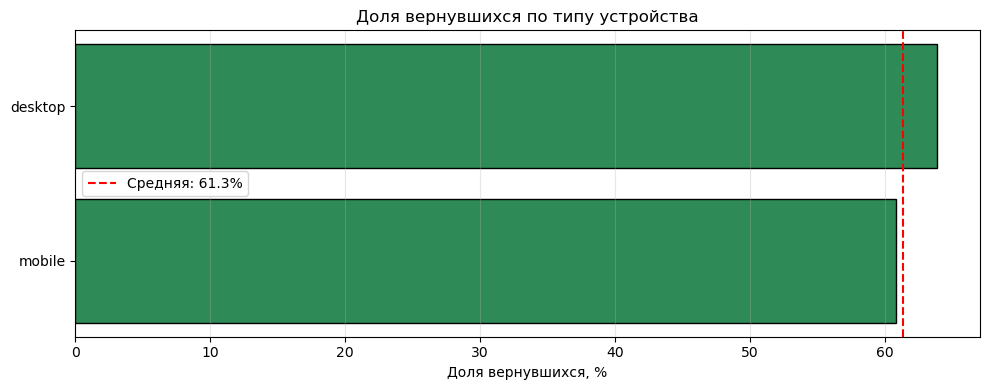

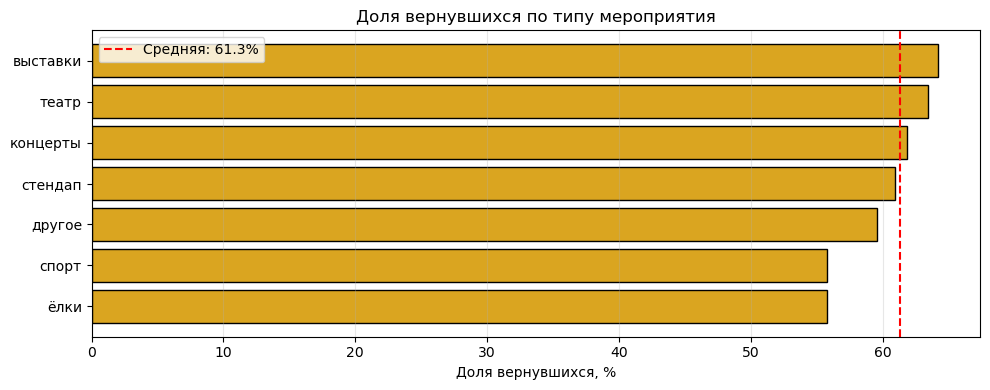

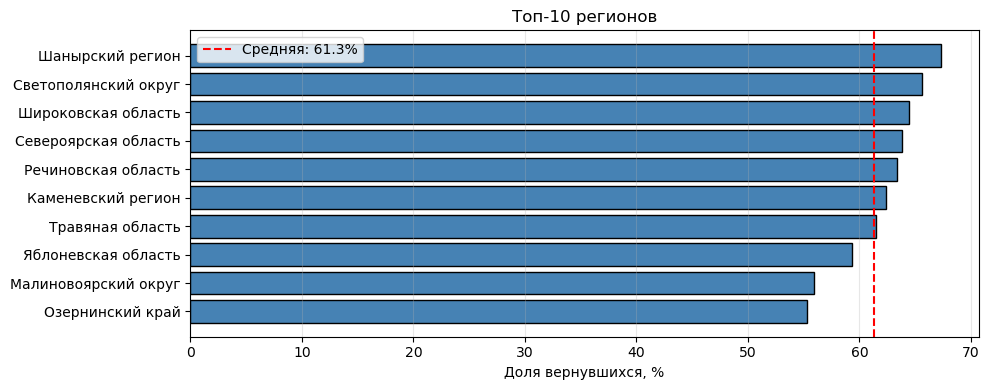

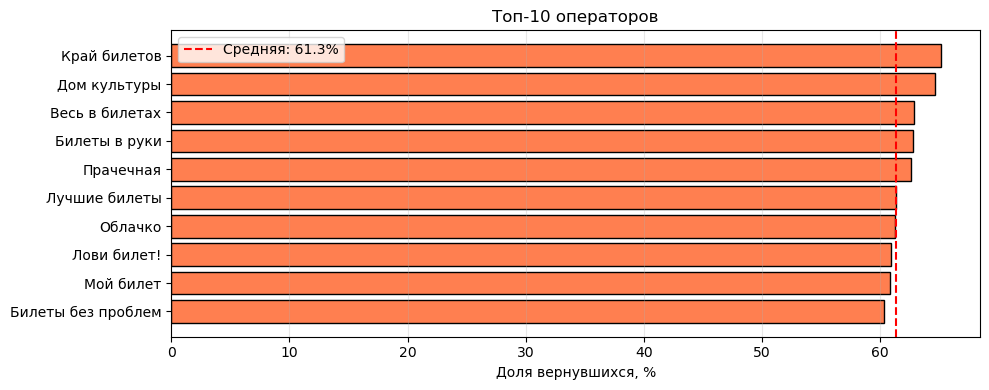

In [56]:
#применение функции для построения графиков:
plot_segment(device_stats, 'Доля вернувшихся по типу устройства', overall_rate, 'seagreen')
plot_segment(event_stats, 'Доля вернувшихся по типу мероприятия', overall_rate, 'goldenrod')
plot_segment(region_stats, 'Топ-10 регионов', overall_rate, 'steelblue')
plot_segment(service_stats,'Топ-10 операторов', overall_rate, 'coral')

Средняя доля вернувшихся пользователей по всей выборке—61.3%. 
Было проанализировано четыре разреза сегментации: тип устройства, тип мероприятия, регион и билетный оператор. Сегменты определяются по атрибуту первого заказа пользователя.

1 По типу устройства:
- Desktop: 65% вернувшихся— выше средней.
- Mobile: 60%— ниже средней.

Пользователи, начинающие с десктопа, возвращаются чаще. Одна из возможных интерпретаций — десктоп предполагает более вдумчивое планирование покупки: у пользователя больше времени изучить сервис, сравнить варианты и вернуться.

2 По типу мероприятия:
- Выставки (65%) и театр (64%)— лидеры по возвратам.
- Ёлки** (55%) и спорт (56%)— самые разовые жанры.

Выставки и театр— регулярный досуг, аудитория возвращается на новые постановки и экспозиции. Ёлки— сезонное событие, спорт—разовые матчи.

3 По регионам (топ-10):
Разброс от 54% (Озернинский край) до 67% (Шанырский регион)—разница в процентах 13. Это значимая разница.
Лидеры: Шанырский регион, Светополянский округ, Широковская и Североярская области.

4 По билетным операторам (топ-10):
Разброс от 58% (Билеты без проблем) до 66% (Край билетов)—разница в процентах 8. Меньше, чем по регионам.
Лидеры: Край билетов, Дом культуры, Весь в билетах.

5 Успешные 'точки входа':
Сегменты с долей возврата выше средней и достаточным размером:

- Desktop (65%)
- Выставки (65%, крупный сегмент)
- Театр (64%, крупный сегмент)
- Шанырский регион (67%)
- Светополянский округ (66%)
- Край билетов (66%, один из крупнейших операторов)
- Дом культуры (65%)

В топ-10 были включены только самые крупные сегменты по числу пользователей. Мелкие сегменты (десятки 
пользователей) не анализировались—их доли нестабильны и могут вводить в заблуждение.

Итог: наиболее перспективные 'точки входа' на Яндекс Афишу—десктопный трафик, жанры 'выставки' и 'театр', а также операторы 'Край билетов' и 'Дом культуры'. Эти сегменты привлекают наиболее лояльную аудиторию, склонную к повторным покупкам.

### Задача 4.1.3. Опираясь на выводы из задач выше, проверьте продуктовые гипотезы:

Гипотеза 1. Тип мероприятия влияет на вероятность возврата на Яндекс Афишу: пользователи, которые совершили первый заказ на спортивные мероприятия, совершают повторный заказ чаще, чем пользователи, оформившие свой первый заказ на концерты.<br>
Гипотеза 2. В регионах, где больше всего пользователей посещают мероприятия, выше доля повторных заказов, чем в менее активных регионах.

#### Проверка Гипотеза 1:

In [57]:
#считаем долю возврата для двух групп
sport_users= user_profile_clean[user_profile_clean['first_event_type']=='спорт']
concert_users= user_profile_clean[user_profile_clean['first_event_type']=='концерты']

sport_return_rate= sport_users['is_two'].mean()*100
concert_return_rate= concert_users['is_two'].mean()*100

In [58]:
print("ГИПОТЕЗА 1:")
print(f"Спорт: {sport_return_rate:.2f}% вернувшихся (n={len(sport_users)})")
print(f"Концерты: {concert_return_rate:.2f}% (n={len(concert_users)})")
print(f"Разница: {sport_return_rate-concert_return_rate:.2f} %")
print()

ГИПОТЕЗА 1:
Спорт: 55.79% вернувшихся (n=794)
Концерты: 61.82% (n=9564)
Разница: -6.02 %



Вывод: гипотеза опровергается. Пользователи, начинающие со спортивных мероприятий, возвращаются реже (55.79%), 
чем пользователи, начинающие с концертов (61.82%). Разница составляет 6.02 в пользу концертов.

Спорт—разовые события. Матчи и турниры привязаны к конкретным датам. Пользователь покупает билет на одно событие и не обязательно возвращается в ближайшее время. Концерты—регулярный досуг.  Люди ходят на концерты разных исполнителей и жанров постоянно, что повышает вероятность повторной покупки.

Размеры выборок достаточны (794 и 9564), поэтому разница устойчива и не объясняется статистической случайностью.

#### Проверка Гипотеза 2:

In [59]:
#коэффициент корреляции Пирсона между размером и долей возврата:
correlation=region_stats['total_users'].corr(region_stats['return_rate'])
correlation_spearman=region_stats['total_users'].corr(region_stats['return_rate'], method='spearman'
)

print(f"Корреляция Пирсона: {correlation:.3f}")
print(f"Корреляция Спирмена: {correlation_spearman:.3f}")

Корреляция Пирсона: 0.127
Корреляция Спирмена: 0.018


In [60]:
#интерпретация
if abs(correlation)<0.2:
    print("связь практически отсутствует.")
elif correlation>0.2:
    print("слабая положительная связь: крупные регионы чуть чаще возвращаются.")
elif correlation<-0.2:
    print("слабая отрицательная связь: крупные регионы чуть реже возвращаются.")

связь практически отсутствует.


Размер региона не является фактором, определяющим возврат пользователей. Гипотеза не подтверждается.

- Корреляция Пирсона: 0.127—очень слабая положительная связь.
- Корреляция Спирмена: 0.018—связь практически отсутствует. 

Скорее поведение пользователя зависит от личных предпочтений, доступности мероприятий, цен, качества сервиса—а не от размера города.
Также в крупных регионах выше конкуренция. Больше мероприятий, но и больше альтернативных билетных сервисов. Пользователь 
может вернуться не на Афишу, а на другую платформу.

Разница между Пирсоном и Спирменом—важный сигнал. Пирсон (0.127) чувствителен к выбросам: пара очень крупных регионов тянетикоэффициент вверх. Но Спирмен (0.018) показывает, что общей ранговой связи нет.

### 4.2. Исследование поведения пользователей через показатели выручки и состава заказа

### Задача 4.2.1. Проследите связь между средней выручкой сервиса с заказа и повторными заказами.

In [61]:
#разделяем пользователей на две группы:
single_users= user_profile_clean[user_profile_clean['orders_count']==1]
returning_users=user_profile_clean[user_profile_clean['orders_count']>=2]

print(f"Однократные покупатели: {len(single_users)}")
print(f"Вернувшиеся покупатели: {len(returning_users)}")

Однократные покупатели: 8363
Вернувшиеся покупатели: 13259


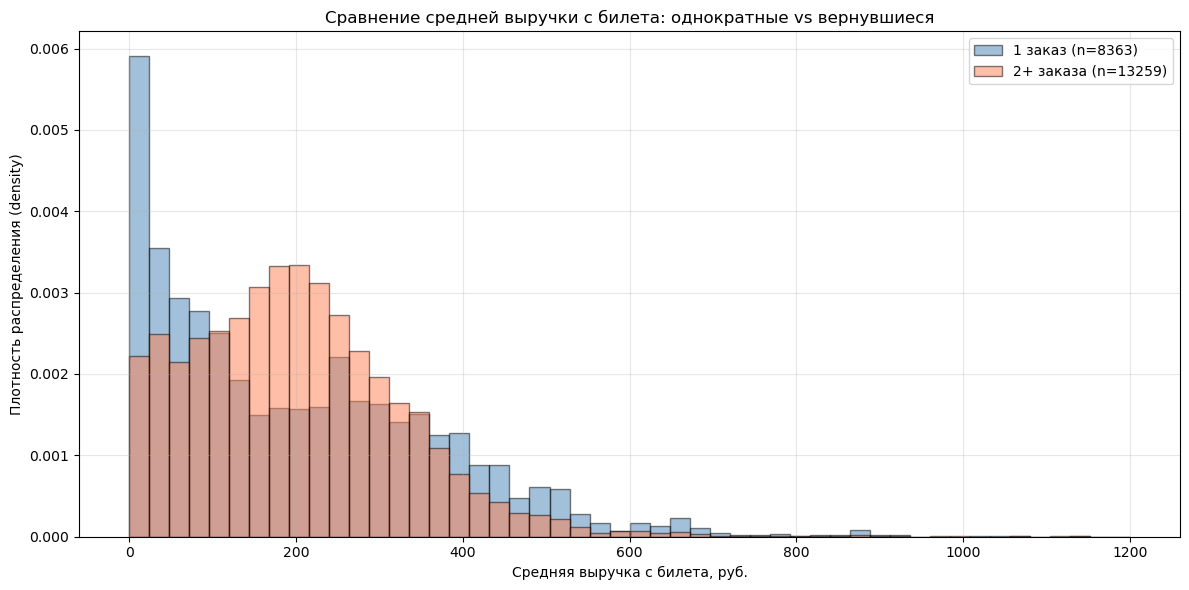

In [62]:
#построение графика:
bins = np.linspace(0, 1200, 51)

plt.figure(figsize=(12, 6))

plt.hist(single_users['avg_revenue_rub'].dropna(),
         bins=bins, alpha=0.5, color='steelblue',
         edgecolor='black', density=True,
         label=f"1 заказ (n={len(single_users)})")

plt.hist(returning_users['avg_revenue_rub'].dropna(),
         bins=bins, alpha=0.5, color='coral',
         edgecolor='black', density=True,
         label=f"2+ заказа (n={len(returning_users)})")

plt.title('Сравнение средней выручки с билета: однократные vs вернувшиеся')
plt.xlabel('Средняя выручка с билета, руб.')
plt.ylabel('Плотность распределения (density)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

1 Однократные покупатели (синий):
- Основная масса— 0–400 руб. за билет.
- Пик— около 50–100 руб. (очень высокий столбик слева).
- Распределение сильно скошено влево: большинство платят мало, но есть длинный хвост до 1000+ руб.

2 Вернувшиеся покупатели (оранжевый):
- Основная масса— 100–500 руб. за билет.
- Пик— около 200–250 руб. (широкий горб правее).
- Распределение более симметричное и смещённое вправо.

Сдвиг распределения вправо у вернувшихся. Пик оранжевой группы находится в районе 200–250 руб, тогда как у синей — в районе 50–100 руб. Это означает, что вернувшиеся тратят с одного билета в среднем больше.

Также наблюдается разная форма распределения:
- У однократных—резкий пик на дешёвых билетах (левый край) и быстрое падение. Классическая картина «разовой покупки дешёвого билета».
- У вернувшихся— плавное распределение с широким «горбом» в среднем диапазоне (150–350 руб). Пользователи возвращаются за билетами разной ценовой категории.

Разный хвост: У однократных длинный хвост до 1000+ руб.— это единичные дорогие разовые покупки. У вернувшихся хвост обрывается около 700–800 руб—они чаще покупают билеты умеренного ценового сегмента.

Точка пересечения около 300 руб. Левые пики синей гистограммы выше—среди однократных больше доля тех, кто платит до 150 руб. Правее 250 руб. доминирует уже оранжевая группа.

Связь между средней выручкой с билета и повторными заказами наблюдается: пользователи, покупающие более дорогие билеты (200–350 руб.), возвращаются чаще, чем те, кто ограничивается дешёвыми билетами (до 150 руб.). Это подтверждает продуктовую гипотезу: чем выше вовлечённость в культурный досуг, тем выше и ценовой уровень, и вероятность повторных покупок.

### Задача 4.2.2. Сравните распределение по средней выручке с заказа в двух группах пользователей:

-совершившие 2–4 заказа;
-совершившие 5 и более заказов.

In [63]:
#cоздаем группы
#Группа 1: 2-4 заказа 
moderate_users= user_profile_clean[
    (user_profile_clean['orders_count']>=2) &
    (user_profile_clean['orders_count']<=4)]

#Группа 2: 5+ заказов
loyal_users= user_profile_clean[user_profile_clean['orders_count']>=5]

print(f"Группа 1 2-4 заказа: {len(moderate_users)}")
print(f"Группа 2 5+ заказов: {len(loyal_users)}")

Группа 1 2-4 заказа: 7143
Группа 2 5+ заказов: 6116


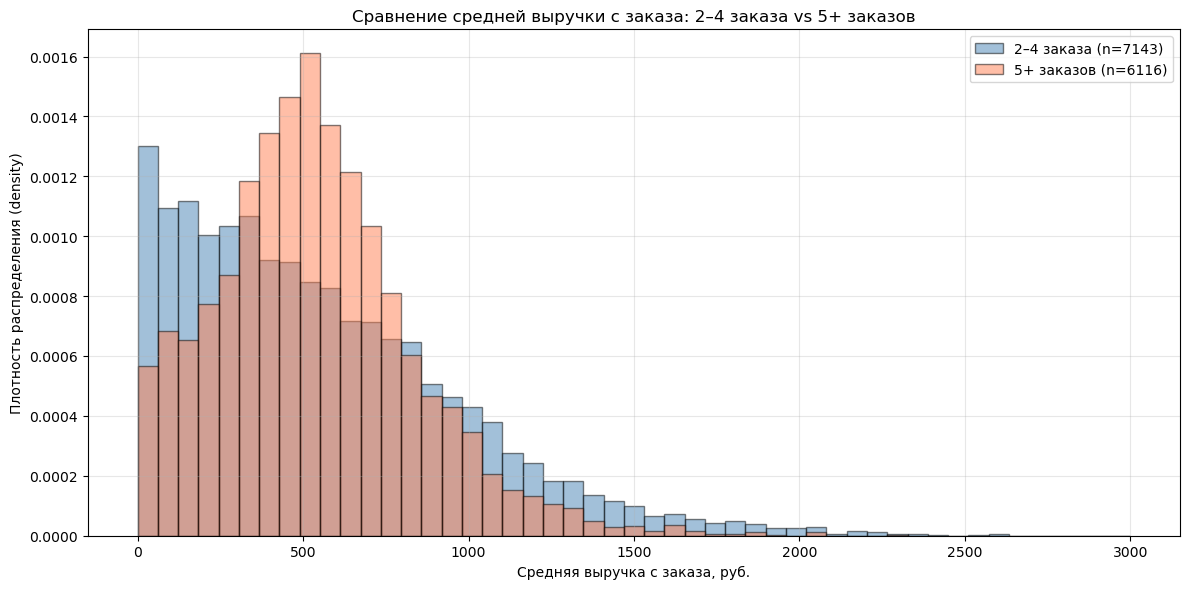

In [64]:
#cтроим диаграмму
bins = np.linspace(0, 3000)

plt.figure(figsize=(12, 6))

#Группа 1: 2-4 заказа
plt.hist(moderate_users['avg_revenue'].dropna(),
         bins=bins, alpha=0.5, color='steelblue',
         edgecolor='black', density=True,
         label=f"2–4 заказа (n={len(moderate_users)})")

#Группа 2: 5+ заказов
plt.hist(loyal_users['avg_revenue'].dropna(),
         bins=bins, alpha=0.5, color='coral',
         edgecolor='black', density=True,
         label=f"5+ заказов (n={len(loyal_users)})")

plt.title('Сравнение средней выручки с заказа: 2–4 заказа vs 5+ заказов')
plt.xlabel('Средняя выручка с заказа, руб.')
plt.ylabel('Плотность распределения (density)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [65]:
#статистические показатели:
print("Группа 1: 2-4 заказа")
print(moderate_users['avg_revenue'].describe())
print()
print("Группа 2: 5+ заказов")
print(loyal_users['avg_revenue'].describe())
print()
# Разница в медианах
med_diff= loyal_users['avg_revenue'].median()-moderate_users['avg_revenue'].median()
print(f"Разница в медианах: {med_diff:.2f} руб.")
# Разница в средних
mean_diff= loyal_users['avg_revenue'].mean()-moderate_users['avg_revenue'].mean()
print(f"Разница в средних: {mean_diff:.2f} руб.")

Группа 1: 2-4 заказа
count    7143.000000
mean      552.318953
std       420.136851
min         0.000000
25%       219.565000
50%       472.470000
75%       799.257500
max      2628.420000
Name: avg_revenue, dtype: float64

Группа 2: 5+ заказов
count    6116.000000
mean      536.605246
std       298.957801
min         0.000000
25%       331.692137
50%       513.309000
75%       700.967911
max      2299.867500
Name: avg_revenue, dtype: float64

Разница в медианах: 40.84 руб.
Разница в средних: -15.71 руб.


Сравнение средней выручки с заказа: 2–4 заказа vs 5+ заказов:

Была построена сравнительная гистограмма распределения avg_revenue (средняя выручка с заказа) для двух групп:
- Группа 1: 2-4 заказа: 7143 человека;
- Группа 2: 5+ заказов: 6116 человек.

Различия по значению средней выручки с заказа между пользователями этих двух групп, но они неоднозначные:

1. По медиане лояльные Группа 2 (5+) тратят больше—513 руб. против 
   472 руб у Группа 1: 2-4 заказа. Разница +40.84 руб. (+8.6%).

2. Группа 2 (5+) тратят чуть меньше—536 руб. против 552 руб.       Разница−15.71 руб. (−2.8%).

3. По разбросу группа 2–4 заказа значительно шире
   (std 420 vs 299). Среди них больше и очень дешёвых, и очень 
   дорогих заказов (максимум 2628 руб. против 2299 у лояльных).


- Группа 2 (5+)—стабильные покупатели среднего чека. Их 
  распределение компактнее: они редко покупают совсем дешёвые 
  билеты (нижний квартиль 332 руб против 220 у группы 2–4) 
  и редко — самые дорогие.
- Группа 1: 2-4 заказа— неоднородная группа. Среди них 
  есть как разовые покупатели дешёвых билетов, так и те, кто 
  делает крупные дорогие покупки (до 2628 руб).
- Частота покупок связана с более высоким типичным чеком, 
  но меньшим разбросом. Группа 2 (5+)— более 
  предсказуемая и качественная аудитория.


### Задача 4.2.3. Проанализируйте влияние среднего количества билетов в заказе на вероятность повторной покупки.

In [66]:
#разделенпие ина сегменты:
#границы интервалов: [1, 2), [2, 3), [3, 5), 5+:
bins= [1, 2, 3, 5, float('inf')]
#список названий для каждого интервала
labels=['1–2 билета', '2–3 билета', '3–5 билетов', '5+ билетов']

user_profile_clean['tickets_segment'] = pd.cut(
    user_profile_clean['avg_tickets'],
    bins=bins,
    labels=labels,
    #правая граница не включается
    right=False,   
)

#вывод количества пользователей в каждом сегменте — в порядке от младшег к старшему
print("Распределение по сегментам:")
print(user_profile_clean['tickets_segment'].value_counts().sort_index())

Распределение по сегментам:
tickets_segment
1–2 билета     2410
2–3 билета     9487
3–5 билетов    9064
5+ билетов      661
Name: count, dtype: int64


In [67]:
#считаем число пользователей и долю вернувшихся
#cчитаем общее число пользователей в каждом сегменте и сколько пользователей вернулись (is_two=1) агрегируя по сегментам:
#observed=True исключая нули и nan
segment_stats= user_profile_clean.groupby('tickets_segment', observed=True).agg(
    total_users=('user_id', 'count'),
    #sum по бинарному столбцу=количество единиц
    returning_users=('is_two', 'sum'),
).reset_index()

#cчитаем долю вернувшихся в процентах:
segment_stats['return_rate']= (
    segment_stats['returning_users']/segment_stats['total_users']*100
).round(2)

#cчитаем долю сегмента от общего числа пользователей
segment_stats['share_of_users']= (
    segment_stats['total_users']/segment_stats['total_users'].sum()*100
).round(2)

#выводим таблицу без индекса:
print("Статистика по сегментам")
print(segment_stats.to_string(index=False))

Статистика по сегментам
tickets_segment  total_users  returning_users  return_rate  share_of_users
     1–2 билета         2410             1235        51.24           11.15
     2–3 билета         9487             6979        73.56           43.88
    3–5 билетов         9064             4921        54.29           41.92
     5+ билетов          661              124        18.76            3.06


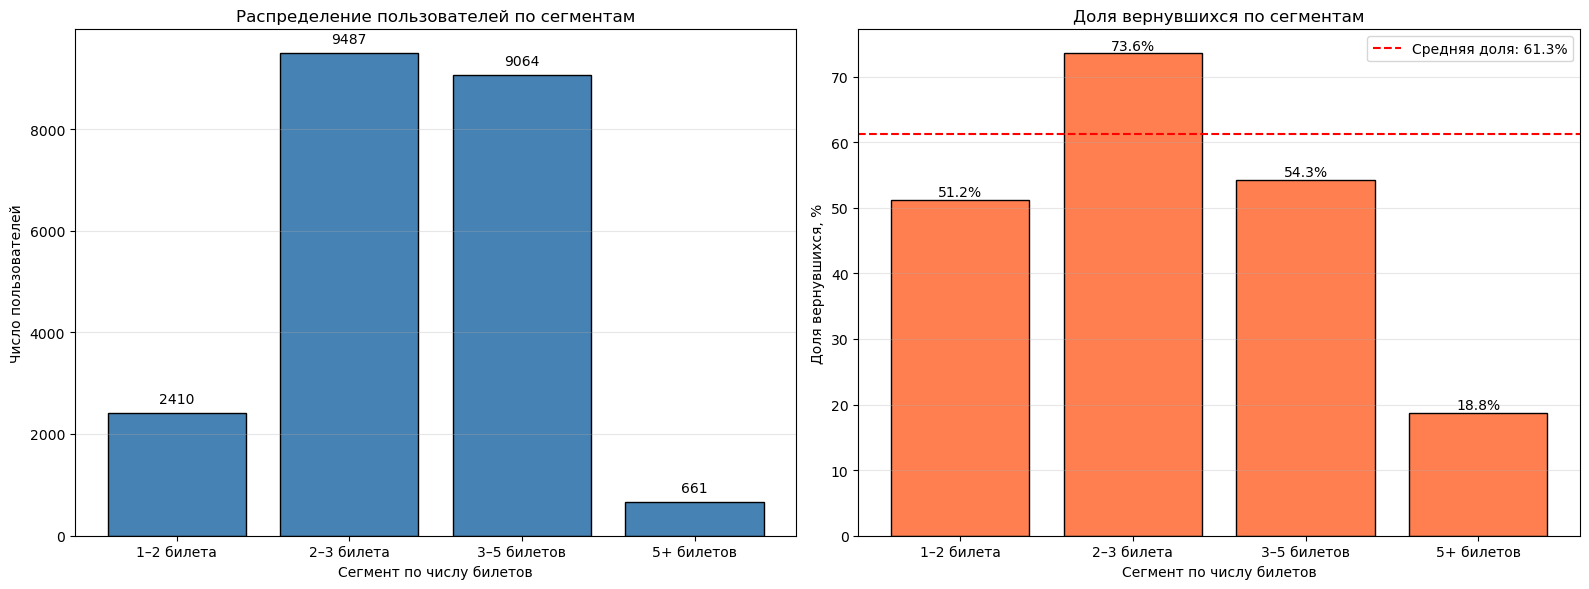

In [68]:
#визуализация:
#создаём фигуру с двумя графиками рядом:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

#график 1. Распределение пользователей по сегментам
#строим столбчатую диаграмму
axes[0].bar(
    segment_stats['tickets_segment'],   # метки сегментов по оси X
    segment_stats['total_users'],       # высота столбцов — число пользователей
    color='steelblue',                  # цвет столбцов
    edgecolor='black',                  # чёрная обводка
)

#заголовок и подписи осей:
axes[0].set_title('Распределение пользователей по сегментам')
axes[0].set_xlabel('Сегмент по числу билетов')
axes[0].set_ylabel('Число пользователей')

#сетка только по оси Y (по X не нужна—там категории)
axes[0].grid(True, axis='y', alpha=0.3)

#добавляем числовые подписи над каждым столбцом
for i, v in enumerate(segment_stats['total_users']):
    axes[0].text(
        i,                # координата X — позиция столбца
        v + 200,          # координата Y — чуть выше вершины столбца
        f"{v}",           # сам текст: число пользователей
        ha='center',      # выравнивание по горизонтали — по центру
        fontsize=10,      # размер шрифта
    )


#график 2. Доля вернувшихся по сегментам

# Считаем среднюю долю возврата по всей выборке
overall_rate = user_profile_clean['is_two'].mean() * 100

# Строим столбчатую диаграмму
axes[1].bar(
    segment_stats['tickets_segment'],   # метки сегментов по оси X
    segment_stats['return_rate'],       # высота столбцов — доля возврата
    color='coral',                      # другой цвет — отличать от первого графика
    edgecolor='black',
)

# Горизонтальная линия среднего значения по всей выборке
axes[1].axhline(
    overall_rate,            # координата Y — средняя доля
    color='red',             # красный цвет
    linestyle='--',          # пунктирная линия
    label=f'Средняя доля: {overall_rate:.1f}%',   # подпись для легенды
)

# Заголовок и подписи осей
axes[1].set_title('Доля вернувшихся по сегментам')
axes[1].set_xlabel('Сегмент по числу билетов')
axes[1].set_ylabel('Доля вернувшихся, %')

# Легенда — покажет подпись красной линии
axes[1].legend()

# Сетка только по оси Y
axes[1].grid(True, axis='y', alpha=0.3)

# Подписи с процентами над каждым столбцом
for i, v in enumerate(segment_stats['return_rate']):
    axes[1].text(
        i,
        v + 0.5,          # чуть выше столбца
        f"{v:.1f}%",      # форматируем как «62.4%» (1 знак после точки)
        ha='center',
        fontsize=10,
    )

plt.tight_layout()   # автоматически расставляет отступы, чтобы подписи не наезжали
plt.show()           # показываем график

Почти 90% пользователей попадают в два средних сегмента—2–3 и 3–5 билетов. Крайние сегменты малы: 1–2 билета (11.5%) и 5+ билетов (3.2%).

#### Влияние среднего количества билетов в заказе на возврат
 Было изучено распределение avg_tickets, разбито количество пользователей на 4 сегмента по среднему числу билетов в заказе и  посчитано для каждого число пользователей и долю вернувшихся.

1. Распределение пользователей по сегментам:
Распределение сконцентрировано. Почти 90% пользователей попадают в два средних сегмента (2–3 и 3–5 билетов). 
Крайние сегменты малы: 1–2 билета—11.5%, 5+ билетов—всего 3.2%.

2. Доля вернувшихся по сегментам:

Было обнаружено две аномалии:
- Сегмент 2–3 билета—аномально высокая доля возврата (73.6%).Это   одновременно самый крупный (45.4% всех пользователей) 
   и самый лояльный сегмент. Ключевая аудитория сервиса.
- Сегмент 5+ билетов—аномально низкая доля возврата (18.8%).
   Это в 4 раза ниже средней (61.3%) и в 4 раза ниже 
   сегмента 2–3 билета. Пользователи покупают 
   много билетов, но почти не возвращаются.

Связь между числом билетов и возвратом нелинейна—есть 
золотая середина:

- 1–2 билета—одиночные разовые покупки.
- 2–3 билета—оптимальный сегмент. Поход в кино/театр парой или 
  с друзьями, регулярный досуг-высокая лояльность (73.6%).
- 3–5 билетов— уже большая компания, менее регулярное событие.
- 5+ билетов—вероятно, не обычные пользователи, а 
  организаторы (например, корпоративные закупки). Возврат низкий (18.8%).

Сегмент 5+ билетов маленький (661 человек), поэтому доля 18.8% может быть нестабильной. Однако разрыв слишком велик, чтобы быть случайностью.

Итого:
- Целевая аудитория для удержания—пользователи, покупающие 
  2–3 билета. Это самый крупный и лояльный сегмент.
- Сегмент 5+ требует отдельного исследования: если это 
  организаторы, для них нужны отдельные механики (скидки на 
  групповые заказы, специальный интерфейс).

### 4.3. Исследование временных характеристик первого заказа и их влияния на повторные покупки


### Задача 4.3.1. Проанализируйте, как день недели, в которой была совершена первая покупка, влияет на поведение пользователей.

In [69]:
#извлекаем день недели из даты первого заказа:
#.dt.day_name() возвращает Monday, Tuesday и ...
user_profile['first_order_dow']= user_profile['first_order_dt'].dt.day_name()

#проверка
print(user_profile['first_order_dow'].value_counts())

first_order_dow
Saturday     3456
Friday       3258
Tuesday      3188
Thursday     3119
Wednesday    3076
Monday       2931
Sunday       2810
Name: count, dtype: int64


In [70]:
#агрегация данных:
#считаем по каждому дню недели число пользователей и долю вернувшихся
#группируем по столбцу с днём недели:
            
dow_stats= user_profile.groupby('first_order_dow').agg(
    #cчитаем общее число пользователей в каждом дне:
    total_users=('user_id', 'count'),
    #cчитаем, сколько пользователей вернулись (is_two=1)
    # sum по бинарному столбцу (число единиц=число вернувшихся)
    returning_users=('is_two', 'sum'),).reset_index()
    #превращаем из индекса в столбец

#cчитаем долю вернувшихся в процентах:
dow_stats['return_rate']=(dow_stats['returning_users']/dow_stats['total_users']*100
).round(2)

#превращаем столбец в категориальный с заданным порядком:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday',
             'Friday', 'Saturday', 'Sunday']
dow_stats['first_order_dow']=pd.Categorical(
    dow_stats['first_order_dow'], categories=day_order, ordered=True)
dow_stats = dow_stats.sort_values('first_order_dow')

print("Статистика по дням недели")
print(dow_stats.to_string(index=False))
print()
#средняя доля возврата для сравнения:
overall_rate=user_profile['is_two'].mean()*100
print(f"Средняя доля возврата: {overall_rate:.2f}%")

Статистика по дням недели
first_order_dow  total_users  returning_users  return_rate
         Monday         2931             1851        63.15
        Tuesday         3188             1978        62.05
      Wednesday         3076             1921        62.45
       Thursday         3119             1857        59.54
         Friday         3258             1948        59.79
       Saturday         3456             2219        64.21
         Sunday         2810             1701        60.53

Средняя доля возврата: 61.70%


In [71]:
#создаём словарь для перевода дней недели на русский
#ключи—английские названия (как их возвращает .dt.day_name())
#значения—русские сокращения для графика и вывода:
day_translation = {
    'Monday':    'Пн',
    'Tuesday':   'Вт',
    'Wednesday': 'Ср',
    'Thursday':  'Чт',
    'Friday':    'Пт',
    'Saturday':  'Сб',
    'Sunday':    'Вс',
}


#применяем словарь к столбцу first_order_dow
# .map(day_translation)—заменяет каждое значение в столбце
# на соответствующее значение из словаря.
dow_stats['day_ru']=dow_stats['first_order_dow'].map(day_translation)

#выводим таблицу с русскими названиями дней
print(
    dow_stats[['day_ru', 'total_users', 'returning_users', 'return_rate']
             ].to_string(index=False)
    #печатаем все строки без обрезки и без индекса
)

day_ru  total_users  returning_users  return_rate
    Пн         2931             1851        63.15
    Вт         3188             1978        62.05
    Ср         3076             1921        62.45
    Чт         3119             1857        59.54
    Пт         3258             1948        59.79
    Сб         3456             2219        64.21
    Вс         2810             1701        60.53


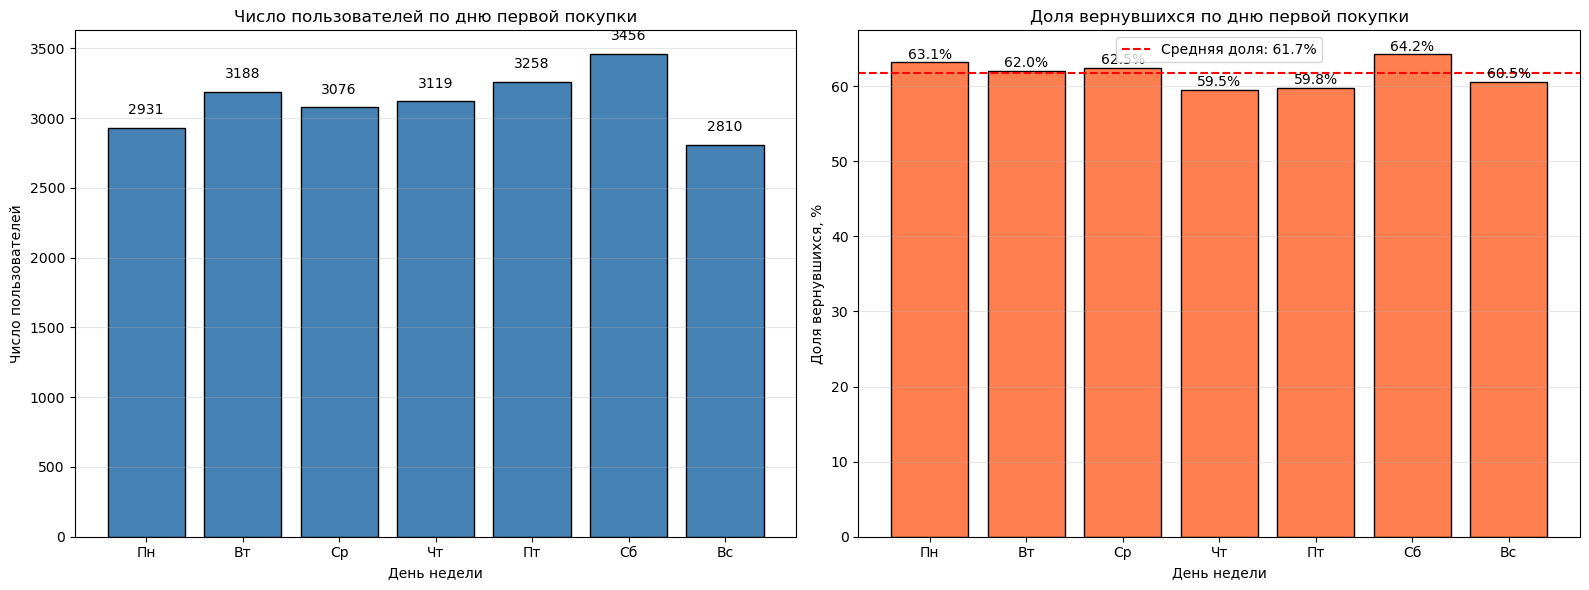

In [72]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

#график 1: число пользователей по дням
axes[0].bar(dow_stats['day_ru'], dow_stats['total_users'],
            color='steelblue', edgecolor='black')
axes[0].set_title('Число пользователей по дню первой покупки')
axes[0].set_xlabel('День недели')
axes[0].set_ylabel('Число пользователей')
axes[0].grid(True, axis='y', alpha=0.3)

#подписи над столбцами
for i, v in enumerate(dow_stats['total_users']):
    axes[0].text(i, v + 100, f"{v}", ha='center', fontsize=10)

#график 2: доля вернувшихся
axes[1].bar(dow_stats['day_ru'], dow_stats['return_rate'],
            color='coral', edgecolor='black')
axes[1].axhline(overall_rate, color='red', linestyle='--',
                label=f'Средняя доля: {overall_rate:.1f}%')
axes[1].set_title('Доля вернувшихся по дню первой покупки')
axes[1].set_xlabel('День недели')
axes[1].set_ylabel('Доля вернувшихся, %')
axes[1].legend()
axes[1].grid(True, axis='y', alpha=0.3)

for i, v in enumerate(dow_stats['return_rate']):
    axes[1].text(i, v + 0.5, f"{v:.1f}%", ha='center', fontsize=10)

plt.tight_layout()
plt.show()

Влияние дня недели первой покупки на возврат:

Было извлечены дни недели из даты первого заказа (first_order_dt), сгруппированы пользователи по этому признаку, посчитаны доли вернувшихся в каждой группе. Визуализированы результаты—число пользователей и доля возврата по дням.

- Разброс между днями: 4.67% (от 59.54% в четверг до 64.21% в субботу).

День недели первой покупки слабо, но заметно влияет на вероятность возврата.

- Лидеры: суббота (64.2%) и понедельник (63.2%)—выше средней на 2.5 и 1.5.
- Аутсайдеры: четверг (59.5%) и пятница (59.8%)—ниже средней на 2.
- Середина: вторник, среда, воскресенье—близко к средней.

1. Суббота и понедельник —осознанные» дни. В выходной и в начале недели люди спокойно планируют досуг, сравнивают 
   варианты и выше вероятность, что они вернутся. Это качественные точки входа.
2. Четверг и пятница —импульсивные дни. Конец рабочей недели, усталость , решения быстрее принимаются , менее осознанно. Пользователь покупает билет на конкретное событие, но не становится постоянным клиентом.
3. Воскресенье (60.5%)—ниже, чем суббота. Возможно, покупки в последний день выходных более импульсивны.

Итого:
- Суббота— самая перспективная точка входа: и число пользователей большое (3456), и доля возврата высокая (64.2%).
- Четверг и пятница—стоит усилить механики вовлечения, чтобы превратить разовую покупку в регулярную.
- День недели—учитывать при планировании маркетинговых кампаний, но не делать его главным фактором удержания.

### Задача 4.3.2. Изучите, как средний интервал между заказами влияет на удержание клиентов.

In [73]:
#разделяем на группы:
#Группа 1: 2–4 заказа:
moderate_users = user_profile_clean[
    (user_profile_clean['orders_count']>=2) &
    (user_profile_clean['orders_count']<=4)
].copy()  
#.copy()—чтобы избежать предупреждений при добавлении столбцов

#Группа 2: 5+ заказов:
loyal_users = user_profile_clean[user_profile_clean['orders_count']>=5].copy()

#Проверка размеров групп:
print(f"Умеренно активные (2–4 заказа): {len(moderate_users)}")
print(f"Лояльные (5+ заказов): {len(loyal_users)}")
print()
# Проверка, что avg_days_between есть и не весь в Nan
print(f"Пропусков в avg_days_between (2–4): {moderate_users['avg_days_between'].isna().sum()}")
print(f"Пропусков в avg_days_between (5+): {loyal_users['avg_days_between'].isna().sum()}")

Умеренно активные (2–4 заказа): 7143
Лояльные (5+ заказов): 6116

Пропусков в avg_days_between (2–4): 0
Пропусков в avg_days_between (5+): 0


In [74]:
#Статистика по двум группам:
print("Средний интервал между заказами (2–4 заказа):")
print(moderate_users['avg_days_between'].describe())
print()
print("Средний интервал между заказами (5+ заказов):")
print(loyal_users['avg_days_between'].describe())
print()
#Разница в медианах и средних
med_diff= loyal_users['avg_days_between'].median()-moderate_users['avg_days_between'].median()
mean_diff= loyal_users['avg_days_between'].mean()-moderate_users['avg_days_between'].mean()
print()
print(f"Разница в медианах (5+ минус 2–4): {med_diff:.2f} дней")
print(f"Разница в средних: {mean_diff:.2f} дней")

Средний интервал между заказами (2–4 заказа):
count    7143.000000
mean       21.162023
std        28.464888
min         0.000000
25%         0.000000
50%         9.000000
75%        33.583333
max       148.000000
Name: avg_days_between, dtype: float64

Средний интервал между заказами (5+ заказов):
count    6116.000000
mean        9.692122
std         7.791376
min         0.000000
25%         3.685714
50%         7.916667
75%        14.000000
max        37.000000
Name: avg_days_between, dtype: float64


Разница в медианах (5+ минус 2–4): -1.08 дней
Разница в средних: -11.47 дней


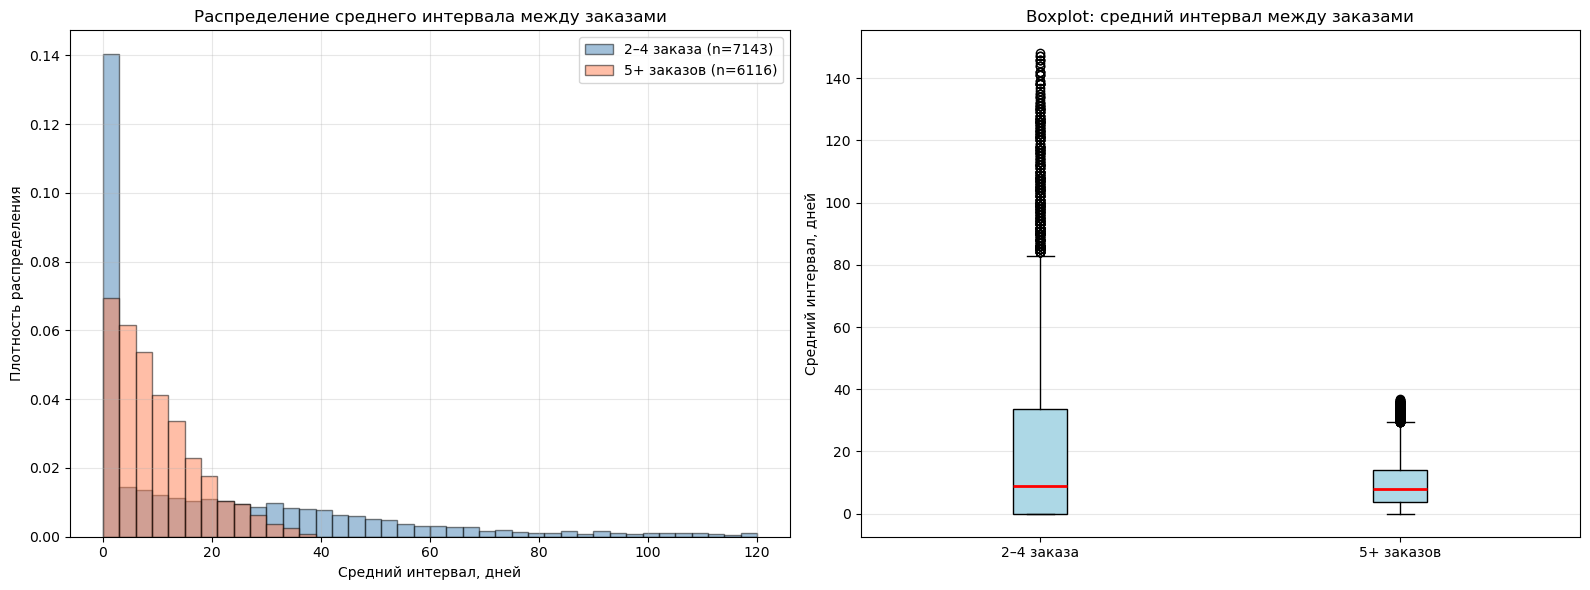

In [75]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

#график 1: сравнительные гистограммы:
bins = np.linspace(0, 120, 41)

axes[0].hist(moderate_users['avg_days_between'].dropna(),
             bins=bins, alpha=0.5, color='steelblue',
             edgecolor='black', density=True,
             label=f'2–4 заказа (n={len(moderate_users)})')

axes[0].hist(loyal_users['avg_days_between'].dropna(),
             bins=bins, alpha=0.5, color='coral',
             edgecolor='black', density=True,
             label=f'5+ заказов (n={len(loyal_users)})')

axes[0].set_title('Распределение среднего интервала между заказами')
axes[0].set_xlabel('Средний интервал, дней')
axes[0].set_ylabel('Плотность распределения')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

#график 2: boxplot для двух групп:

box_data = [
    moderate_users['avg_days_between'].dropna(),
    loyal_users['avg_days_between'].dropna(),
]
axes[1].boxplot(box_data, tick_labels=['2–4 заказа', '5+ заказов'],
                patch_artist=True,
                boxprops=dict(facecolor='lightblue', color='black'),
                medianprops=dict(color='red', linewidth=2))

axes[1].set_title('Boxplot: средний интервал между заказами')
axes[1].set_ylabel('Средний интервал, дней')
axes[1].grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

- Средний интервал у лояльных в 2.2 раза короче—9.7 дней против 21.2.
- Разброс у лояльных в 3.6 раза меньше—std 7.8 против 28.5.
- Медиана отличается слабо (7.9 и 9.0), но среднее—очень сильно (из-за хвоста выбросов у группы 2–4).
- 75-й перцентиль: у лояльных 14 дней, у умеренных 33.6—почти в 2.4 раза больше.

### Влияние среднего интервала между заказами на удержание
Было разделено количество пользователей на две группы по числу заказов —2–4 заказа (n=7143) и 5+ заказов (n=6116). Для каждой группы рассчитана статистика по столбцу avg_days_between (средний интервал между заказами пользователя). 
Визуализированы распределения через сравнительные гистограммы и boxplot.

Интервал между заказами сильно влияет на вероятность возврата.

1. Средний интервал у 5+ заказов в 2.2 раза короче—9.7 дней против 21.2. Пользователи с 5+ заказами покупают билеты 
   в среднем раз в 1.5 недели.
2. Разброс у 5+ заказов в 3.6 раза меньше—std 7.8 дней против 28.5. Их поведение стабильно и предсказуемо.
3. 75-й перцентиль: у лояльных 14 дней, у умеренных 33.6—почти в 2.4 раза больше. То есть даже медленные лояльные 
   покупают чаще, чем «средние» умеренные.
4. 5+ заказы имеют длинный хвост выбросов—до 148 дней. Среди них много пользователей с большими паузами.


- Регулярность=лояльность. 5+ заказы пользователи ходят на мероприятия часто и стабильно. Это ядро активной аудитории.
- 2–4 заказа—неоднородная группа.  Среди них есть и активные, и почти ушедшие. Большой разброс и длинный хвост— признак высокого риска оттока.
- Длинный интервал—сигнал оттока.** Если пользователь давно не покупал билет (интервал 20+ дней), вероятность его возврата падает. Это ключевой триггер для маркетинга.


Итого:
1. Регулярность—главный признак лояльности. Пользователи с коротким интервалом (5–10 дней) — самые ценные.
2. Триггеры для возврата.Если интервал превышает медиану (10+ дней), стоит активизировать коммуникацию. Это снизит риск оттока.
3. Пользователи с интервалом>30 дней—кандидаты на реактивацию.



### 4.4. Корреляционный анализ количества покупок и признаков пользователя


In [76]:

from phik import phik_matrix
from phik.report import plot_correlation_matrix

#определяем список столбцов для анализа
#берём признаки профиля и целевую переменную orders_count:
profile_cols= [
    'orders_count',              
    'avg_revenue',               
    'avg_revenue_rub',           
    'avg_tickets',              
    'avg_days_between',          
    'is_two',                    
    'is_five',                   
    'first_device',              
    'first_region',              
    'first_service',            
    'first_event_type']

#определяем интервальные столбцы:
#interval_cols—список числовых столбцов, которые phi_k должен обрабатывать как непрерывные (а не как категории)
interval_cols= [
    'orders_count',
    'avg_revenue',
    'avg_revenue_rub',
    'avg_tickets',
    'avg_days_between',
]

print("Столбцы для анализа:", profile_cols)
print("Интервальные столбцы:", interval_cols)

Столбцы для анализа: ['orders_count', 'avg_revenue', 'avg_revenue_rub', 'avg_tickets', 'avg_days_between', 'is_two', 'is_five', 'first_device', 'first_region', 'first_service', 'first_event_type']
Интервальные столбцы: ['orders_count', 'avg_revenue', 'avg_revenue_rub', 'avg_tickets', 'avg_days_between']


In [77]:

#считаем матрицу phi_k:
# phik_matrix принимает: df—датафрейм с нужными столбцами и interval_cols—какие столбцы считать числовыми:
phik_matrix_all=phik_matrix(
    user_profile_clean[profile_cols],
    interval_cols=interval_cols,
)

#cмотрим корреляции с orders_count, сортируем по убыванию
print("Корреляции с orders_count по всей выборке")
print(phik_matrix_all['orders_count'].sort_values(ascending=False))

Корреляции с orders_count по всей выборке
orders_count        1.000000
is_five             0.614585
is_two              0.308675
avg_days_between    0.281109
avg_tickets         0.225326
avg_revenue         0.219467
first_region        0.117162
avg_revenue_rub     0.088398
first_service       0.028571
first_event_type    0.028444
first_device        0.026483
Name: orders_count, dtype: float64


In [78]:

#проверяем разброс orders_count

print("Распределение orders_count")
print(user_profile_clean['orders_count'].describe())
print()
print("Топ-10 значений")
print(user_profile_clean['orders_count'].value_counts().head(10))
print()
print("Доли")
print((user_profile_clean['orders_count'].value_counts(normalize=True).head(10)*100).round(2))

Распределение orders_count
count    21622.000000
mean         6.496624
std         14.310784
min          1.000000
25%          1.000000
50%          2.000000
75%          5.000000
max        152.000000
Name: orders_count, dtype: float64

Топ-10 значений
orders_count
1     8363
2     3571
3     2171
4     1401
5      969
6      702
7      541
8      453
9      385
10     287
Name: count, dtype: int64

Доли
orders_count
1     38.68
2     16.52
3     10.04
4      6.48
5      4.48
6      3.25
7      2.50
8      2.10
9      1.78
10     1.33
Name: proportion, dtype: float64


In [79]:

#cоздаём сегменты по числу заказов
#проверяем, есть ли уже столбец orders_segment в профиле
if 'orders_segment' not in user_profile_clean.columns:
    user_profile_clean['orders_segment']=pd.cut(
        #разбиваем число заказов на интервалы  (0,1],(1,4] , 5+
        user_profile_clean['orders_count'],   
        bins=[0, 1, 4, float('inf')], 
        # названия сегментов:
        labels=['1 заказ', '2–4 заказа', '5+ заказов'], 
        #правая граница включается
        right=True,                            
    )
    print("Столбец orders_segment создан")
else:
    print("Столбец orders_segment уже существует")

#проверка
# Смотрим, сколько пользователей в каждом сегменте
print("Распределение по сегментам:")
print(user_profile_clean['orders_segment'].value_counts().sort_index())


Столбец orders_segment создан
Распределение по сегментам:
orders_segment
1 заказ       8363
2–4 заказа    7143
5+ заказов    6116
Name: count, dtype: int64


In [80]:

#считаем phi_k с orders_segment вместо orders_count
#меняем целевую переменную: теперь это orders_segment (категория)
profile_cols_seg= [
    'orders_segment',            
    'avg_revenue',
    'avg_revenue_rub',
    'avg_tickets',
    'avg_days_between',
    'is_two',
    'is_five',
    'first_device',
    'first_region',
    'first_service',
    'first_event_type']

# interval_cols теперь без orders_count (он превратился в категорию)
interval_cols_seg=[
    'avg_revenue',
    'avg_revenue_rub',
    'avg_tickets',
    'avg_days_between']

phik_matrix_seg=phik_matrix(
    user_profile_clean[profile_cols_seg],
    interval_cols=interval_cols_seg,
)

#смотрим корреляции с orders_segment
print("Корреляции с orders_segment по сегментам")
print(phik_matrix_seg['orders_segment'].sort_values(ascending=False))

Корреляции с orders_segment по сегментам
orders_segment      1.000000
is_two              1.000000
is_five             1.000000
avg_days_between    0.388236
avg_tickets         0.383043
avg_revenue         0.325259
avg_revenue_rub     0.294773
first_region        0.123894
first_service       0.082321
first_event_type    0.041037
first_device        0.017415
Name: orders_segment, dtype: float64


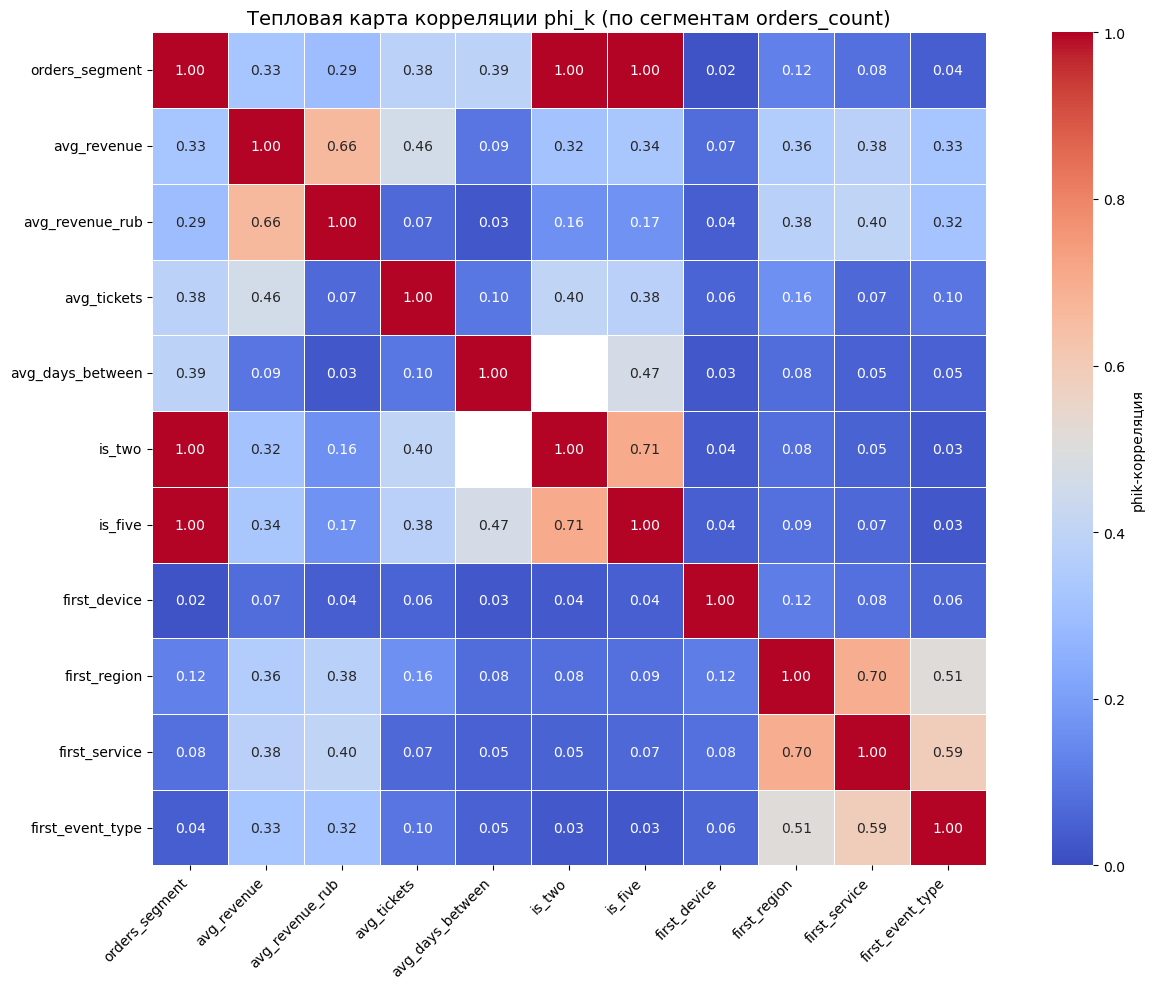

In [81]:

# визуализация — тепловая карта
plt.figure(figsize=(14, 10))

sns.heatmap(
    phik_matrix_seg,
    annot=True,           # показывать числа в ячейках
    fmt='.2f',            # формат — 2 знака после точки
    cmap='coolwarm',      # цветовая схема: синий → красный
    vmin=0, vmax=1,       # диапазон значений
    square=True,          # квадратные ячейки
    linewidths=0.5,       # линии между ячейками
    cbar_kws={'label': 'phik-корреляция'},
)

plt.title('Тепловая карта корреляции phi_k (по сегментам orders_count)', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Корреляционный анализ phi_k: связь признаков с числом заказов

Был рассчитан коэффициент корреляции phi_k между признаками профиля и числом заказов. Сначала проведен анализ по всей выборке 
с непрерывным 'orders_count', затем—по сегментам ('1 заказ', '2–4 заказа', '5+ заказов'), чтобы устранить эффект скошенности данных.

- Проверка разброса 'orders_count':
Данные сильно скошены: 38.7% пользователей имеют 1 заказ, 16.5%—2, 10.0%—3. Дальше доли резко падают. Из-за этого корреляции по всей 
выборке оказались заниженными.

1. Результаты по всей выборке (топ-5):
- is_five: 0.615
- is_two: 0.309
- avg_days_between: 0.281
- avg_tickets: 0.225
- avg_revenue: 0.219

2 Результаты по сегментам (топ-5):
- is_two: 1.000
- is_five: 1.000
- avg_days_between: 0.388
- avg_tickets: 0.383
- avg_revenue: 0.325

- Наиболее связаны с числом заказов признаки is_two, is_five, avg_days_between и avg_tickets.

Признаки is_two и is_five: производные от`orders_count. Они показывают '2+ заказа' и '5+ заказов', то есть 
буквально определяются числом заказов. Их высокая корреляция (1.00) —ожидаема и не несёт новой информации.

3. Реальные предикторы числа заказов:
- avg_days_between(phi_k = 0.388)—средний интервал между заказами. Чем короче интервал, тем больше заказов у пользователя. 
   Это самый сильный поведенческий признак лояльности.

- avg_tickets(phi_k = 0.383)—среднее число билетов в заказе. Пользователи, покупающие больше билетов, чаще возвращаются.

- avg_revenue(phi_k = 0.325) —средняя выручка с заказа. Умеренная связь—те, кто тратит больше, чаще возвращаются.

- avg_revenue_rub(phi_k = 0.295)—выручка с билета. Слабая-умеренная связь.

Слабые признаки:
- first_region(0.124), first_service(0.082), first_event_type(0.041), first_device(0.017 —практически не связаны с числом заказов.

Число заказов пользователя определяется поведенческими признакам —как часто он покупает (интервал), сколько билетов 
берёт за раз, сколько тратит. Демографические признаки (устройство, регион, оператор, жанр первого мероприятия) почти не влияют на лояльность.

Итого: для прогнозирования числа заказов и удержания пользователей стоит опираться на поведенческие признаки, а не на демографические.

### 5. Общий вывод и рекомендации

1. Информация о данных и их подготовке:
В рамках проекта проанализированы данные билетного сервиса Яндекс Афиша — информация о заказах, пользователях, мероприятиях и географии. Исходный датасет содержал 290 611 заказов от 21 838 уникальных пользователей за 2024 год.

На этапе предобработки:
- реализовано приведение выручки к единой валюте. Заказы были представлены в двух валютах—рублях (98.4%) и тенге (1.6%). Для конвертации использован датасет с курсом тенге ('final_tickets_tenge_df.csv'). Результат сохранён в новый столбец 'revenue_rub'.
- проведена обработка аномалий. В столбце 'revenue_rub' обнаружено 381 отрицательное значение—явные ошибки выгрузки. Они удалены. Оставлено 5526 нулевых значений как возможные промо-билеты.
- проведена фильтрация выбросов. Выявлены крупные заказы до 81 174 руб. Удалено 2825 строк (0.97%).
- итоговый объём: после очистки осталось 287405 строк (98.90% исходных данных). Удалено всего 1.10%—это не влияет на репрезентативность выборки.
- построение профиля пользователя. Для каждого пользователя собраны: даты первого и последнего заказа, атрибуты первого заказа (устройство, регион, оператор, жанр), общее число заказов, средняя выручка, среднее число билетов, средний интервал между заказами. Добавлены признаки 'is_two' (2+ заказа) и 'is_five' (5+ заказов).
- оптимизация типов данных. Числовые столбцы приведены к компактным типам ('int32', 'int16'), категориальные—к 'category'. Память сокращена примерно в 2 раза.

2. Основные результаты анализа:

2.1. Распределение пользователей по числу заказов:
Данные сильно скошены:
- 1 заказ— 38.68% пользователей
- 2 заказа— 16.52%
- 3 заказа— 10.04%
- 4 заказа— 6.48%
- 5+ заказов— 28.28%

Среднее число заказов—6.50, медиана—2. Это говорит о длинном хвосте: большинство пользователей делают 1–3 заказа, но есть небольшая группа "активных", которая тянет среднее вверх.

Ключевые метрики:
- Доля пользователей с 2+ заказами—61.7%
- Доля пользователей с 5+ заказами—29.0%

2.2. Признаки первого заказа и их связь с возвратом:
Средняя доля возврата по выборке—61.7%.

По устройству первого заказа:
- Desktop —65% возврата (выше средней)
- Mobile —60% (ниже средней)

По типу мероприятия:
- Выставки(65%) и театр(64%) — лидеры
- Концерты(62%)—на уровне средней
- Спорт(56%) и ёлки(55%)—аутсайдеры

По регионам (топ-10): разброс от 54% (Озернинский край) до 67% (Шанырский регион).
По билетным операторам (топ-10): разброс от 58% (Билеты без проблем) до 66% (Край билетов).

2.3. Проверка продуктовых гипотез:

Гипотеза 1. Пользователи, начинающие со спортивных мероприятий, возвращаются чаще, чем начавшие с концертов.
Результат: ОПРОВЕРГНУТА.
- Спорт: 55.79% (n=794)
- Концерты: 61.82% (n=9 564)
- Разница: −6.02% в пользу концертов

Спорт—разовые события, концерты—регулярный досуг.

Гипотеза 2. В регионах с большим числом пользователей выше доля повторных заказов.

Результат: ОПРОВЕРГНУТА.
- Корреляция Пирсона: 0.127
- Корреляция Спирмена: 0.018

Связь между размером региона и возвратом отсутствует.

2.4. Связь выручки с возвратом:

По средней выручке с заказа:
- 2–4 заказа: медиана 472 руб.
- 5+ заказов: медиана 513 руб.

Разница в медианах: +40.84 руб. (+8.6%). Но среднее у лояльных ниже—из-за длинного хвоста крупных разовых заказов в группе 2–4.
По средней выручке с билета: у вернувшихся распределение смещено вправо—они тратят больше (150–250 руб против 100–150 у однократных).

2.5. Связь числа билетов с возвратом:

Обнаружена нелинейная зависимость:
Доля возврата по сегментам:
1–2 билета: 51.2%
2–3 билета: 73.6%
3–5 билетов: 54.3%
5+ билетов: 18.8% |

Золотая середина—2–3 билета. Это самый крупный (45.4%) и самый лояльный сегмент. Крайности проваливаются: одиночки (51.2%) и организаторы групп (18.8%).

2.6. Временные характеристики:

Средний интервал между заказами:
- 2–4 заказа: 21.16 дней
- 5+ заказов: 9.69 дней
- Разница: 11.47 дней (в 2.2 раза)

Регулярность покупок напрямую связана с удержанием.

День недели первой покупки:
- Лидеры: суббота (64.2%) и понедельник (63.2%)
- Аутсайдеры: четверг (59.5%) и пятница (59.8%)
- Разброс: 4.67—умеренный эффект

2.7. Корреляционный анализ phi_k:

По всей выборке (с 'orders_count'):
- is_five: 0.615
- is_two: 0.309
- avg_days_between: 0.281
- avg_tickets: 0.225
- avg_revenue: 0.219
- first_region: 0.117
- first_service: 0.029
- first_event_type: 0.028
- first_device: 0.026

По сегментам (с 'orders_segment'):
- is_two, is_five: 1.000 (производные от целевой переменной)
- avg_days_between: 0.388
- avg_tickets: 0.383
- avg_revenue: 0.325
- avg_revenue_rub: 0.295
- first_region: 0.124
- first_service: 0.082
- first_event_type: 0.041
- first_device: 0.017

3. Дополнительные наблюдения:

3.1. Мобильный трафик доминирует. 80% заказов совершены с мобильных устройств, 20%— с десктопа. При этом десктопные пользователи возвращаются чаще.
3.2. Валюта. 98.4% заказов— в рублях, 1.6%— в тенге. Сервис ориентирован на российский рынок.
3.3. Операторы. Всего 36 билетных операторов, но топ-3 покрывают 50% заказов.
3.4. География. 81 регион и 352 города. Каменевский регион даёт 31% заказов, Глиногорск— 31% по городам.

Рекомендации бизнесу:
На что обратить внимание:
1 Сегмент '2–3 билета'—ключевая аудитория (45% пользователей, 73.6% возврата). Рекомендуется включить персональные подборки, программа лояльности.
2. Регулярность=лояльность. Если интервал>14 дней—триггерные письма и push.
3. Триггерные кампании для спящих».Промокод на 2-ю покупку для однократных пользователей (38.7% выборки).
4. Десктопный трафик— более лояльный. Не отказываться от канала.
5. Жанры "театр" и "выставки"—точки входа лояльной аудитории. Рекомендуется развивать абонементы и подписки.
6. Сегмент "5+ билетов" (18.8% возврата)—вероятно, B2B-организаторы. Требует отдельного исследования.

Что НЕ делать:
- Не сегментировать по размеру региона—связи нет.
- Не фокусироваться только на мобильном или только на десктопе.
- Не ожидать лояльности от спорта и ёлок—разовые события.

Главный принцип: лояльность определяется поведением(частота покупок, размер заказа), а не демографией (регион, устройство).
